<h1 style="text-align: center;"> Telco Customer Churn Prediction using Machine Learning </h1>

# 1. Importing Libraries and Defining the Graphical Style

In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from IPython.display import display, HTML
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

colors = ["#2B2D42", "#2EC4B6"]

sns.set_style("whitegrid")

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_blue",
    ["#2B2D42", "white", "#2EC4B6"]
)

# 2. Dataset Downloading and Loading

In [5]:
# =========================================================
# Dataset Downloading and Loading
# =========================================================

# Installation of kagglehub
!pip install kagglehub

# =========================================================
# Downloading the dataset
# =========================================================

path = kagglehub.dataset_download(
    "abbas829/telco-customer-churn-dataset"
)

print("Path to dataset files:", path)

# =========================================================
# Loading the dataset
# =========================================================

file_path = f"{path}/Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

# =========================================================
# Dataset preview
# =========================================================

df.head()

Using Colab cache for faster access to the 'telco-customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Dataset Overview

In [6]:
# ======================================================
# Variable Profile Function
# ======================================================

def column_profile(df, target=None):

    rows = []
    n = len(df)

    for c in df.columns:

        miss = df[c].isna().mean() * 100
        nunique = df[c].nunique(dropna=True)
        dtype = str(df[c].dtype)

        top_vals = df[c].value_counts(dropna=True).head(3)

        top_str = "; ".join(
            [f"{idx}:{val}" for idx, val in top_vals.items()]
        )

        rows.append({
            "column": c,
            "dtype": dtype,
            "missing_%": round(miss, 2),
            "n_unique": int(nunique),
            "top3_values": top_str
        })

    prof = pd.DataFrame(rows)

    prof = prof.sort_values(
        ["missing_%", "n_unique"],
        ascending=[False, False]
    )

    return prof

In [7]:
# ======================================================
# Variable Profiling Visualization
# ======================================================

# Generate column profile
prof = column_profile(df)

# ======================================================
# Styled Table
# ======================================================

styled_prof = (

    prof.style

    .set_properties(**{
        "background-color": "#F8F9FA",
        "color": "#2B2D42",
        "border-color": "#D9D9D9",
        "font-size": "11pt"
    })

    # Header styling
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2B2D42"),
                ("color", "white"),
                ("font-size", "12pt"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        },

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "20pt"),
                ("font-weight", "bold"),
                ("color", "#2B2D42"),
                ("text-align", "center"),
                ("padding", "15px")
            ]
        }
    ])

    # Missing values gradient
    .background_gradient(
        subset=["missing_%"],
        cmap="BuGn"
    )

    # Unique values gradient
    .background_gradient(
        subset=["n_unique"],
        cmap=custom_cmap
    )

    # Text alignment
    .set_properties(**{
        "text-align": "center"
    })

    # Table title
    .set_caption(
        "Telco Customer Churn Dataset - Variable Profiling"
    )
)

# Display styled table
styled_prof

,column,dtype,missing_%,n_unique,top3_values
0,customerID,object,0.000000,7043,3186-AJIEK:1; 7590-VHVEG:1; 5575-GNVDE:1
19,TotalCharges,object,0.000000,6531,:11; 20.2:11; 19.75:9
18,MonthlyCharges,float64,0.000000,1585,20.05:61; 19.85:45; 19.95:44
5,tenure,int64,0.000000,73,1:613; 72:362; 2:238
17,PaymentMethod,object,0.000000,4,Electronic check:2365; Mailed check:1612; Bank transfer (automatic):1544
7,MultipleLines,object,0.000000,3,No:3390; Yes:2971; No phone service:682
8,InternetService,object,0.000000,3,Fiber optic:3096; DSL:2421; No:1526
9,OnlineSecurity,object,0.000000,3,No:3498; Yes:2019; No internet service:1526
10,OnlineBackup,object,0.000000,3,No:3088; Yes:2429; No internet service:1526
11,DeviceProtection,object,0.000000,3,No:3095; Yes:2422; No internet service:1526


In [8]:
# =========================
# Duplicate Values Detection
# =========================

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


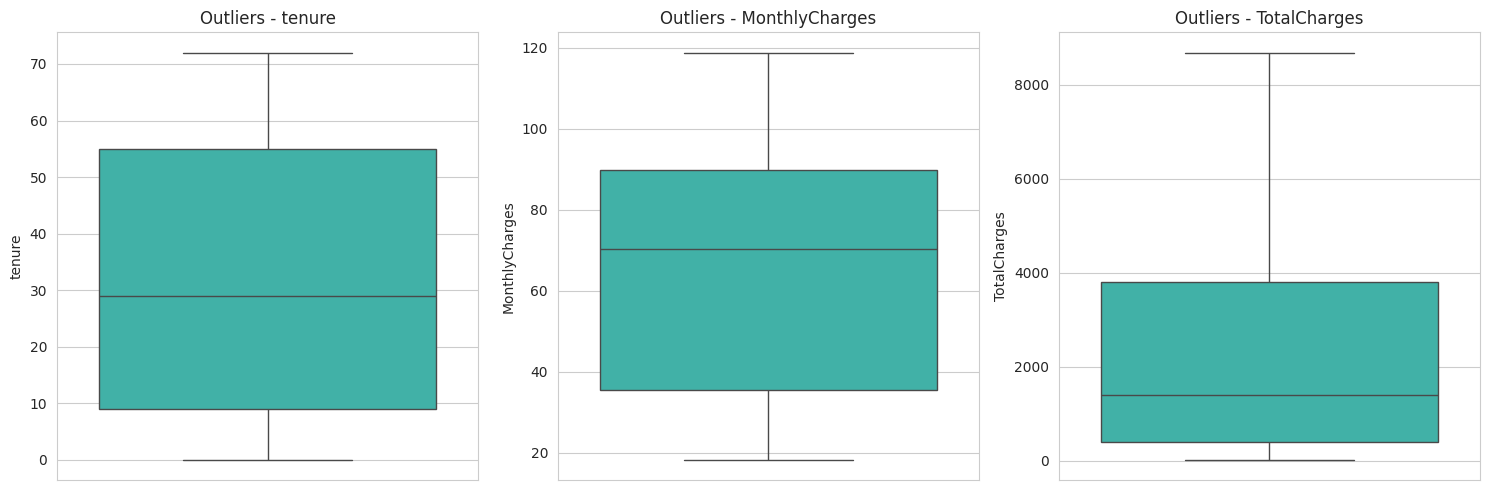

In [9]:
# ======================================================
# TotalCharges Variable Conversion
# ======================================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ======================================================
# Numerical Variables Selection
# ======================================================

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# ======================================================
# Outlier Detection Visualization
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):

    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="#2EC4B6"
    )

    axes[i].set_title(f"Outliers - {col}")

plt.tight_layout()
plt.show()

# Dataset Overview and Initial Interpretation

The Telco Customer Churn dataset contains information about 7,043 customers from a telecommunications company, along with their churn status. It includes demographic variables, subscription details, and information about the services used by customers.

The dataset contains features such as gender, customer tenure, contract type, monthly charges, total charges, payment method, and several service-related variables including internet service, online security, technical support, streaming services, and device protection. The target variable, Churn, indicates whether a customer left the company or remained subscribed.

The initial analysis shows that the dataset is generally clean, with very few missing values. However, the TotalCharges column requires conversion to a numerical format because some values are stored as text. The dataset is also imbalanced, as most customers remain loyal to the company while a smaller proportion have churned.

Several variables appear particularly relevant for explaining customer churn, especially contract type, tenure, monthly charges, internet service, and payment method. Customers with shorter contracts, higher monthly fees, and shorter tenure seem more likely to leave the company.

Overall, this dataset is highly suitable for Exploratory Data Analysis (EDA) and for developing Machine Learning models aimed at predicting customer churn and supporting customer retention strategies.

# 4. Exploratory Data Analysis (EDA)

## 4.1 Target Variable Distribution (Churn)

/tmp/ipykernel_2610/3271343742.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(


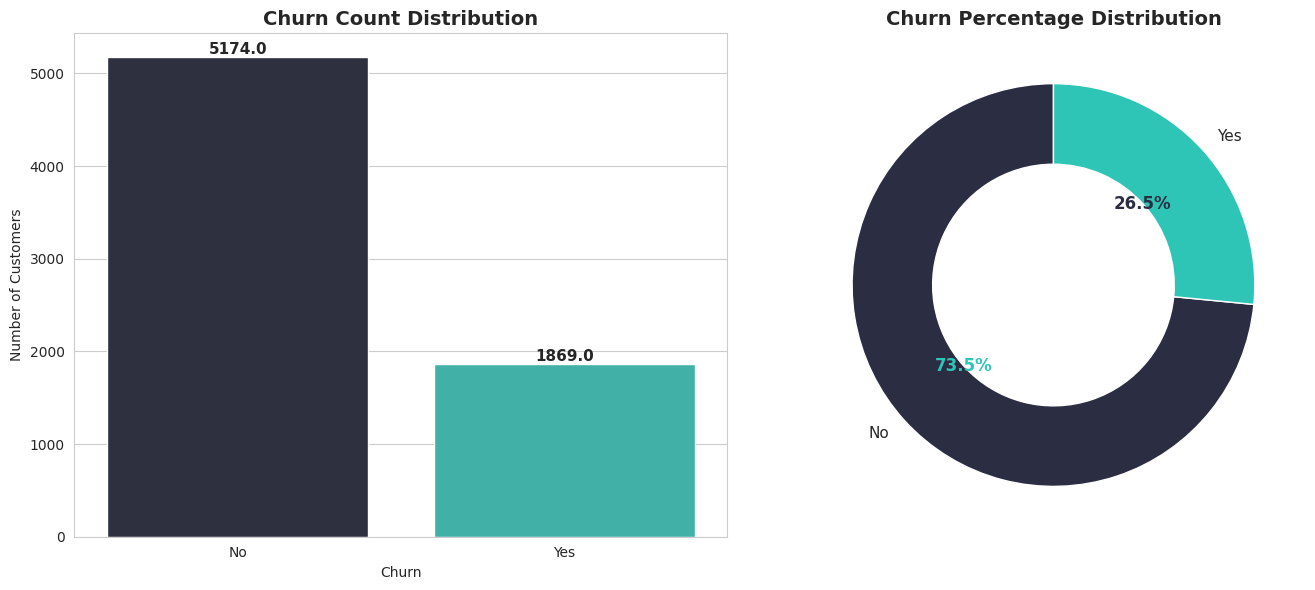

In [10]:
# ======================================================
# Target Variable Distribution Analysis
# ======================================================

# Data
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

# Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ======================================================
# 1. Churn Count Distribution
# ======================================================

ax1 = sns.countplot(
    x="Churn",
    data=df,
    palette=colors,
    ax=axes[0]
)

# Add values
for p in ax1.patches:

    height = p.get_height()

    ax1.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax1.set_title(
    "Churn Count Distribution",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Churn")
ax1.set_ylabel("Number of Customers")

# ======================================================
# 2. Churn Percentage Distribution
# ======================================================

wedges, texts, autotexts = axes[1].pie(
    churn_percent,
    labels=churn_percent.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4},
    textprops={"fontsize": 11}
)

text_colors = ["#2EC4B6", "#2B2D42"]

for i, autotext in enumerate(autotexts):

    autotext.set_color(text_colors[i])
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)

axes[1].set_title(
    "Churn Percentage Distribution",
    fontsize=14,
    fontweight="bold"
)

# Layout
plt.tight_layout()

plt.show()

## Interpretation – Target Variable Distribution (Churn)

The target variable Churn shows the distribution of customers who left the company versus those who remained subscribed. The analysis reveals that the majority of customers belong to the “No” class, meaning they did not cancel their subscription. In comparison, a smaller proportion of customers belong to the “Yes” class, indicating that they churned.

This indicates that the dataset is imbalanced, since there are significantly more loyal customers than customers who left the company. This imbalance is important to consider during the modeling phase because a Machine Learning model could become biased toward the majority class and fail to correctly identify customers at risk of churning.

Therefore, it is necessary to use evaluation metrics better suited for imbalanced datasets, such as recall, precision, F1-score, and ROC AUC, rather than relying only on accuracy. This approach helps ensure that the model effectively detects customers who are likely to churn.

## 4.2 Demographic Variables Analysis

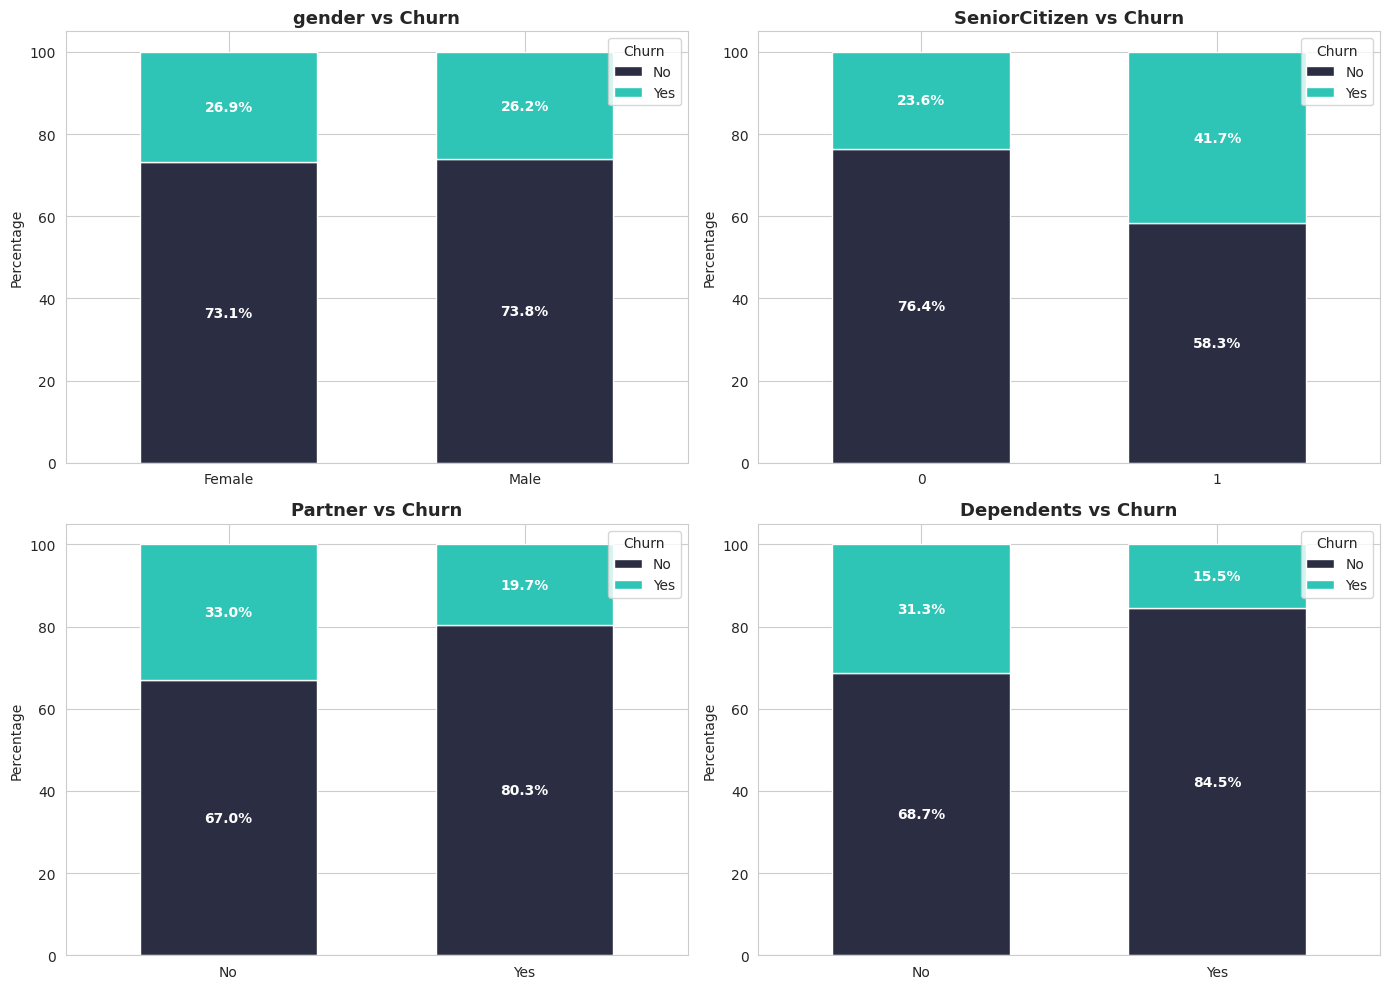

In [11]:
# ======================================================
# Demographic Variables Analysis by Churn
# ======================================================

# Demographic variables
demo_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, col in enumerate(demo_cols):

    # Percentage cross-tabulation
    data = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    # Visualization
    data.plot(
        kind="bar",
        stacked=True,
        color=colors,
        ax=axes[i],
        width=0.6
    )

    # Add percentages
    for container in axes[i].containers:

        axes[i].bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    # Titles and labels
    axes[i].set_title(
        f"{col} vs Churn",
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel("")

    axes[i].legend(
        title="Churn",
        loc="upper right"
    )

    axes[i].tick_params(
        axis="x",
        rotation=0
    )

# Layout
plt.tight_layout()

plt.show()

## Interpretation – Demographic Variables Analysis

In this section, the impact of demographic variables on customer churn was analyzed.

Regarding gender, there is no significant difference between male and female customers. The churn rates are almost similar for both groups, which suggests that gender is not an important factor in explaining customer churn.

For the SeniorCitizen variable, a much stronger difference can be observed. Senior customers have a significantly higher churn rate (around 41%) compared to non-senior customers (around 23%). This indicates that older customers are more likely to leave the company.

Concerning the Partner variable, customers without a partner show a much higher churn rate (around 33%) than customers who have a partner (around 19%). This may suggest that customers living with a partner are generally more stable and less likely to switch providers.

Similarly, for the Dependents variable, customers without dependents have a higher churn rate (around 31%) compared to customers with dependents (around 15%). This could indicate that customers with family responsibilities tend to remain more loyal to the company.

Overall, the most influential demographic variables in this analysis appear to be senior citizen status, having a partner, and having dependents, while gender does not seem to have a significant impact on customer churn.

## 4.3 Customer Tenure Analysis

/tmp/ipykernel_2610/3547994048.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


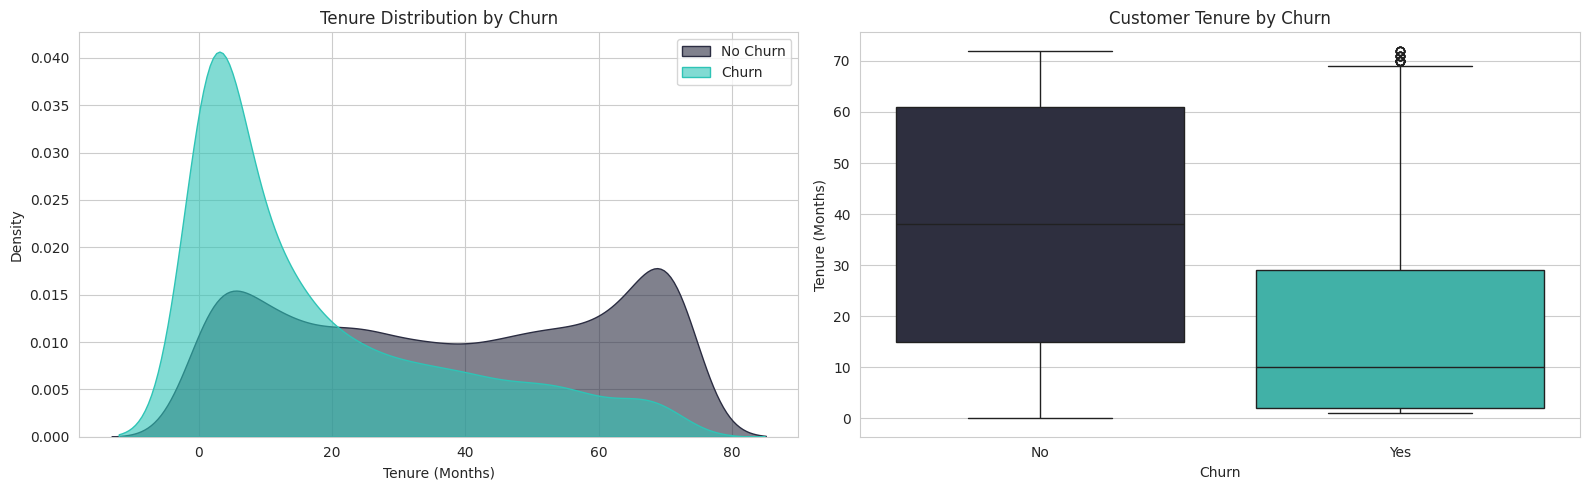

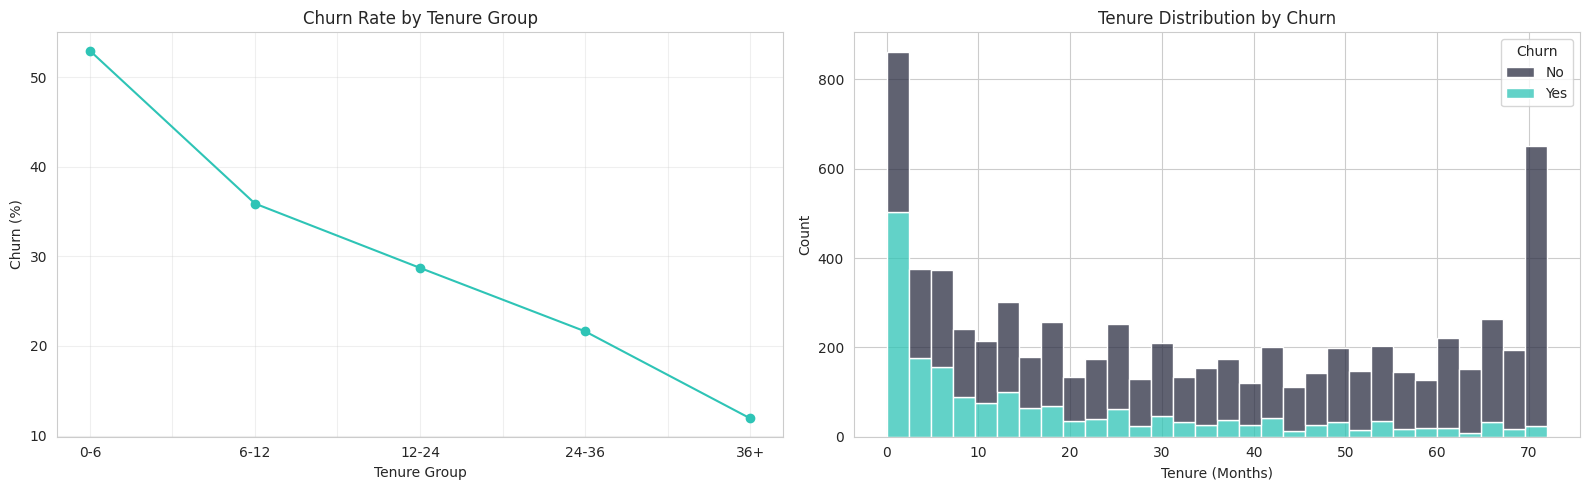

In [12]:
# ======================================================
# Customer Tenure Analysis by Churn
# ======================================================

# ======================================================
# Figure 1 : Tenure Distribution and Boxplot
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE distribution for customers without churn
sns.kdeplot(
    data=df[df["Churn"] == "No"],
    x="tenure",
    fill=True,
    color=colors[0],
    label="No Churn",
    alpha=0.6,
    ax=axes[0]
)

# KDE distribution for customers with churn
sns.kdeplot(
    data=df[df["Churn"] == "Yes"],
    x="tenure",
    fill=True,
    color=colors[1],
    label="Churn",
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Tenure Distribution by Churn")
axes[0].set_xlabel("Tenure (Months)")
axes[0].legend()

# Boxplot of tenure by churn
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df,
    palette=colors,
    ax=axes[1]
)

axes[1].set_title("Customer Tenure by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()


# ======================================================
# Figure 2 : Churn Rate by Tenure Group
# ======================================================

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 36, 72],
    labels=["0-6", "6-12", "12-24", "24-36", "36+"],
    include_lowest=True
)

rate = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Churn rate curve
rate["Yes"].plot(
    kind="line",
    marker="o",
    color=colors[1],
    ax=axes[0]
)

axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_xlabel("Tenure Group")
axes[0].set_ylabel("Churn (%)")
axes[0].grid(alpha=0.3)

# Stacked histogram of tenure
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack",
    palette=colors,
    ax=axes[1]
)

axes[1].set_title("Tenure Distribution by Churn")
axes[1].set_xlabel("Tenure (Months)")

plt.tight_layout()
plt.show()

## Interpretation of Churn Rate by Customer Tenure

The analysis of the tenure variable, which represents customer seniority, reveals very clear patterns regarding customer churn.

First, the tenure distribution by churn status highlights a significant difference between the two groups. Customers who left the company (Churn = Yes) are mainly concentrated at lower tenure values, meaning they have a short relationship with the company. In contrast, customers who remained subscribed (Churn = No) are more distributed across higher tenure values, indicating stronger long-term loyalty.

The boxplot further confirms this observation: customers who churned have a much lower median tenure compared to customers who stayed. This clearly suggests that customer longevity is a major factor influencing customer retention.

In addition, the segmentation of customers into tenure groups shows a decreasing churn trend. New customers (0–6 months and 6–12 months) have the highest churn rates, while the churn rate gradually decreases as customer tenure increases. Customers with more than 24 months of tenure appear significantly more stable and loyal.

## 4.4 Analysis of Contracts, Billing, and Payment Methods

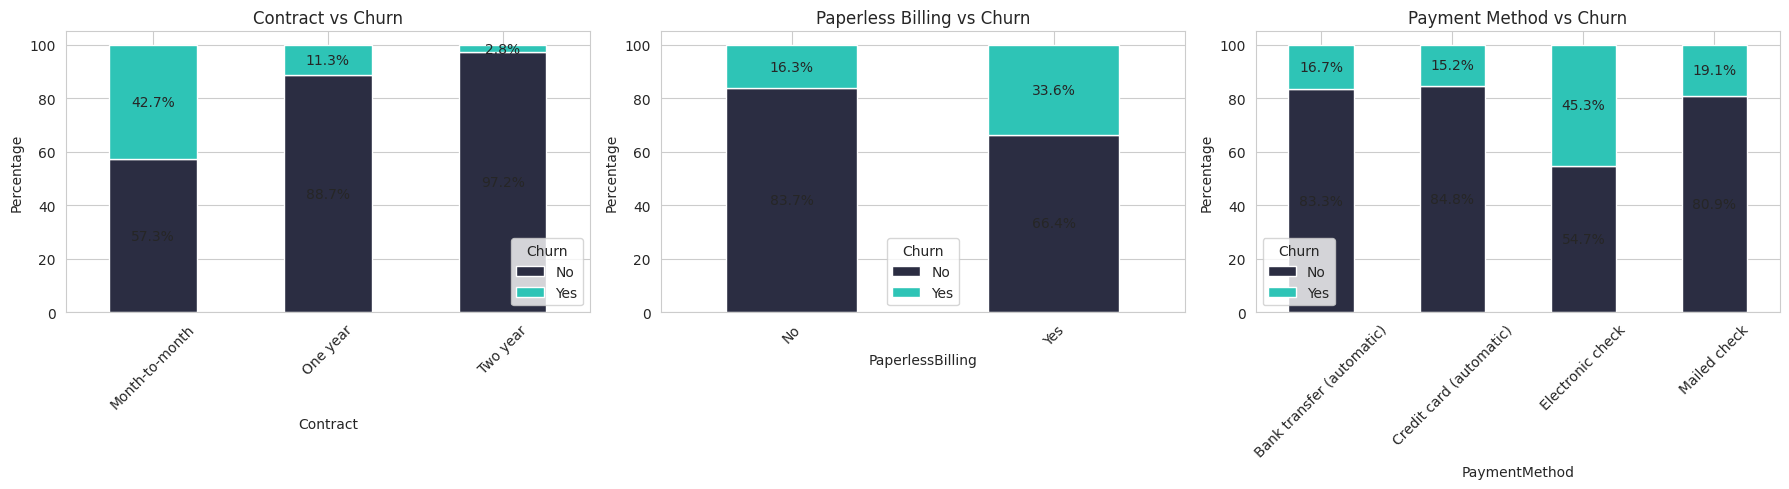

Churn,No,Yes
Contract,,
Month-to-month,57.3%,42.7%
One year,88.7%,11.3%
Two year,97.2%,2.8%
Churn,No,Yes
PaperlessBilling,,
No,83.7%,16.3%
Yes,66.4%,33.6%
Churn,No,Yes
PaymentMethod,,


In [13]:
# ======================================================
# Analysis of Contracts, Billing, and Payment Methods by Churn
# ======================================================

# ======================================================
# Churn Rate Calculation
# ======================================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100


# ======================================================
# Churn Rate Visualization
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

contract_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=colors
)

paperless_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=colors
)

payment_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    color=colors
)

titles = [
    "Contract vs Churn",
    "Paperless Billing vs Churn",
    "Payment Method vs Churn"
]

for i, ax in enumerate(axes):

    ax.set_title(titles[i])
    ax.set_ylabel("Percentage")
    ax.tick_params(axis="x", rotation=45)

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            label_type="center"
        )

plt.tight_layout()
plt.show()


# ======================================================
# Table Styling Function
# ======================================================

def style_table(df, title):

    return (
        df.style
        .set_caption(title)
        .format("{:.1f}%")
        .background_gradient(cmap=custom_cmap)
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #2B2D42",
            "font-size": "14px"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("color", "#2B2D42"),
                    ("font-size", "18px"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("margin-bottom", "10px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2B2D42"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("font-size", "14px")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("width", "100%")
                ]
            }
        ])
    )


# ======================================================
# Horizontal Table Display
# ======================================================

html = f"""
<div style="display:flex; justify-content:space-between; gap:20px;">

<div style="flex:1; min-width:300px;">
{style_table(contract_churn, "Contract vs Churn").to_html()}
</div>

<div style="flex:1; min-width:300px;">
{style_table(paperless_churn, "Paperless Billing vs Churn").to_html()}
</div>

<div style="flex:1; min-width:300px;">
{style_table(payment_churn, "Payment Method vs Churn").to_html()}
</div>

</div>
"""

display(HTML(html))

## Interpretation – Analysis of Contracts, Billing, and Payment Methods

The analysis of the variables Contract, PaperlessBilling, and PaymentMethod provides a better understanding of how customer engagement conditions influence churn behavior.

First, the contract type has a major impact on customer retention. Customers with a month-to-month contract show a significantly higher churn rate compared to customers with long-term contracts such as one-year or two-year plans. This indicates that lower contractual commitment increases the likelihood of customer departure.

Next, the PaperlessBilling variable reveals a slight difference between the two groups. Customers using electronic billing tend to churn slightly more than those using traditional billing methods. This may be explained by the fact that these customers are generally more digitally oriented and therefore more sensitive to competitive offers, making it easier for them to switch providers.

Finally, the payment method also plays an important role. Customers using Electronic Check exhibit a much higher churn rate compared to customers using automatic payment methods such as bank transfer or credit card payments. This suggests that automated payment systems improve customer retention by reducing active cancellation behaviors.

## 4.5 Analysis of Subscribed Services

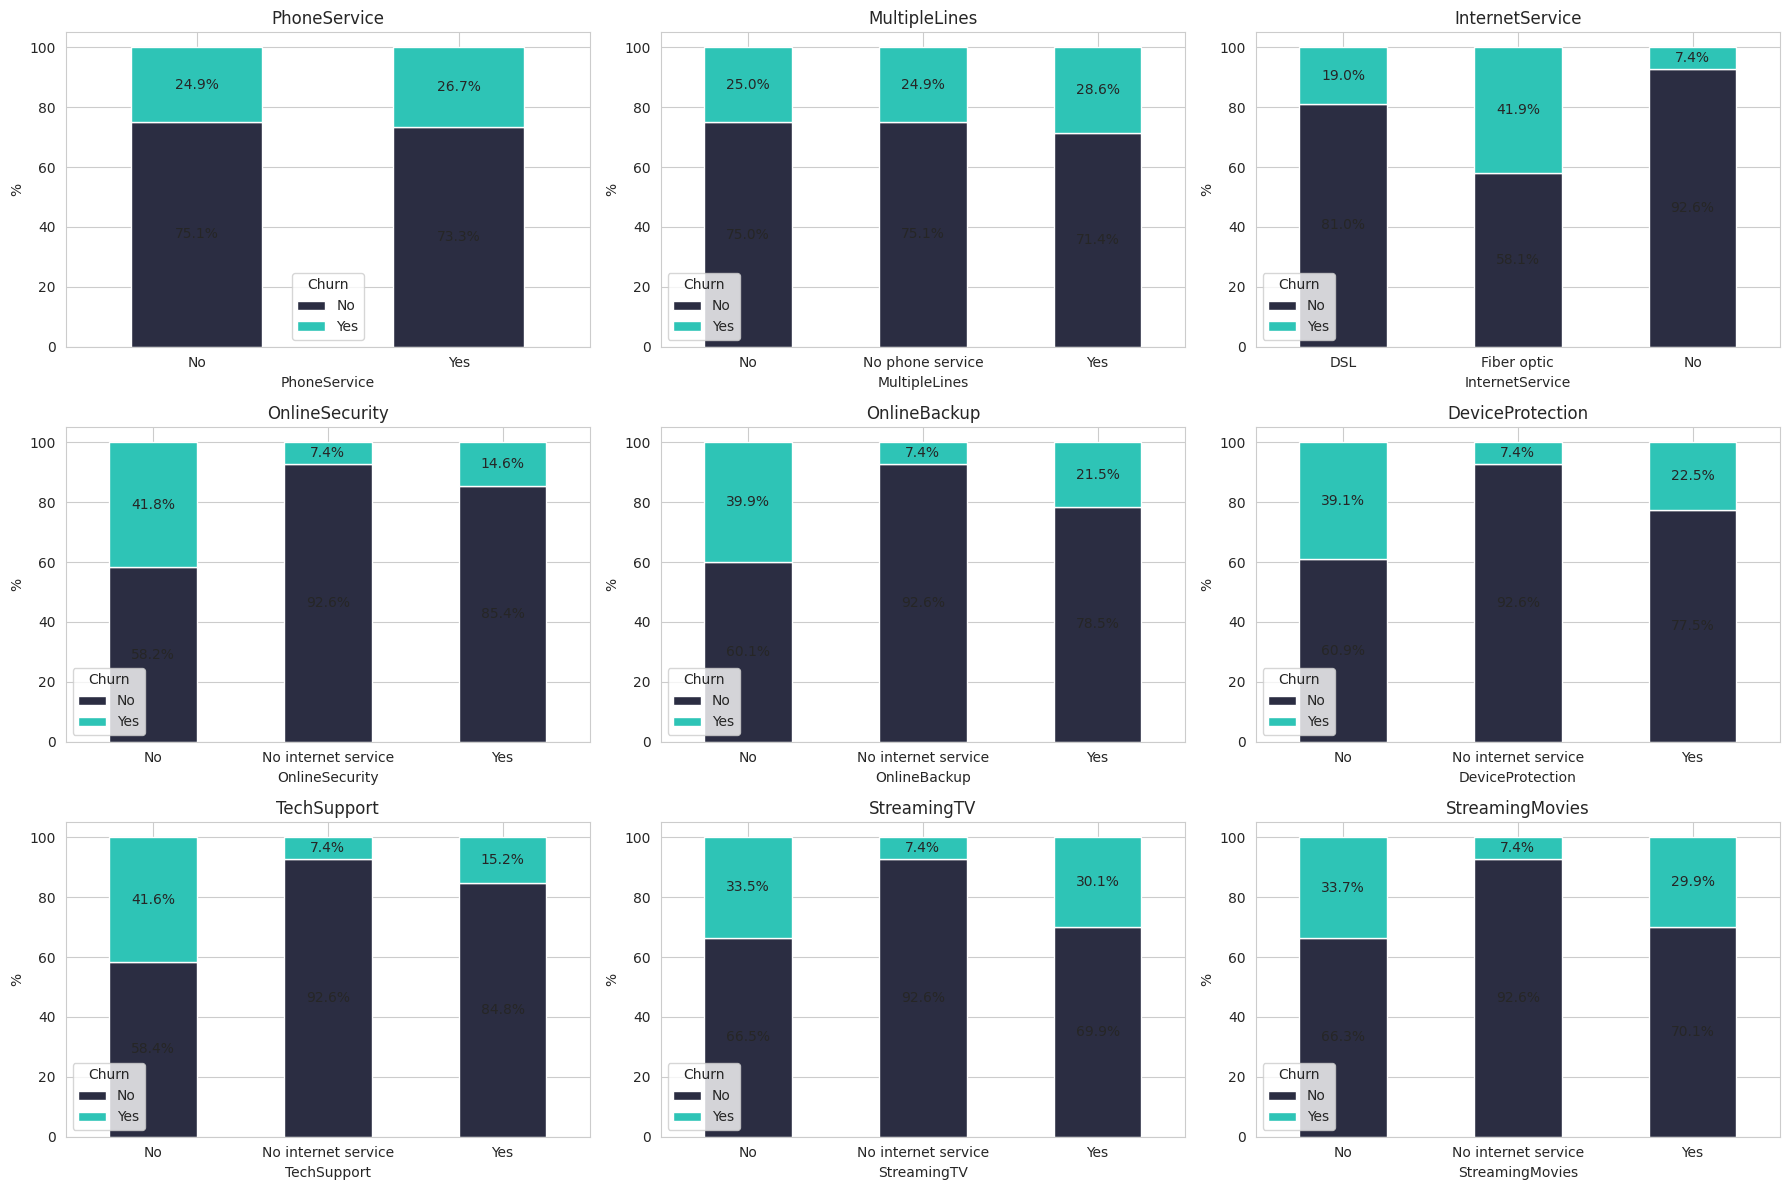

In [14]:
# ======================================================
# Analysis of Subscribed Services by Churn
# ======================================================

# Service-related variables
services_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# ======================================================
# Subscribed Services Visualization by Churn
# ======================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes = axes.flatten()

for i, col in enumerate(services_cols):

    # Percentage cross-tabulation
    data = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    # Visualization
    data.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=colors
    )

    # Titles and labels
    axes[i].set_title(col)
    axes[i].set_ylabel("%")

    axes[i].tick_params(
        axis="x",
        rotation=0
    )

    # Display percentages
    for container in axes[i].containers:

        axes[i].bar_label(
            container,
            fmt="%.1f%%",
            label_type="center"
        )

# Layout
plt.tight_layout()

plt.show()

## Interpretation – Analysis of Subscribed Services

The analysis of subscribed services helps identify which types of services influence customer churn behavior.

First, services related to security and technical support play an important role in customer retention. Customers who do not subscribe to services such as OnlineSecurity or TechSupport exhibit a higher churn rate. This suggests that these services strengthen customer trust and reduce the likelihood of leaving the company.

In addition, customers who subscribe to extra services such as DeviceProtection or OnlineBackup also appear to be more loyal. Conversely, the absence of these services is often associated with higher churn, which may indicate that customers with fewer subscribed services are generally less engaged.

Regarding streaming services (StreamingTV and StreamingMovies), their impact on churn is less significant. Some differences can be observed, but they are smaller compared to security and support services.

Finally, Internet service type also shows an important difference. Customers using fiber optic internet tend to churn more frequently than those using DSL or having no internet service. This may be related to higher customer expectations or greater price sensitivity among fiber optic users.

## 4.6 Analysis of Financial Variables

/tmp/ipykernel_2610/3049114294.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


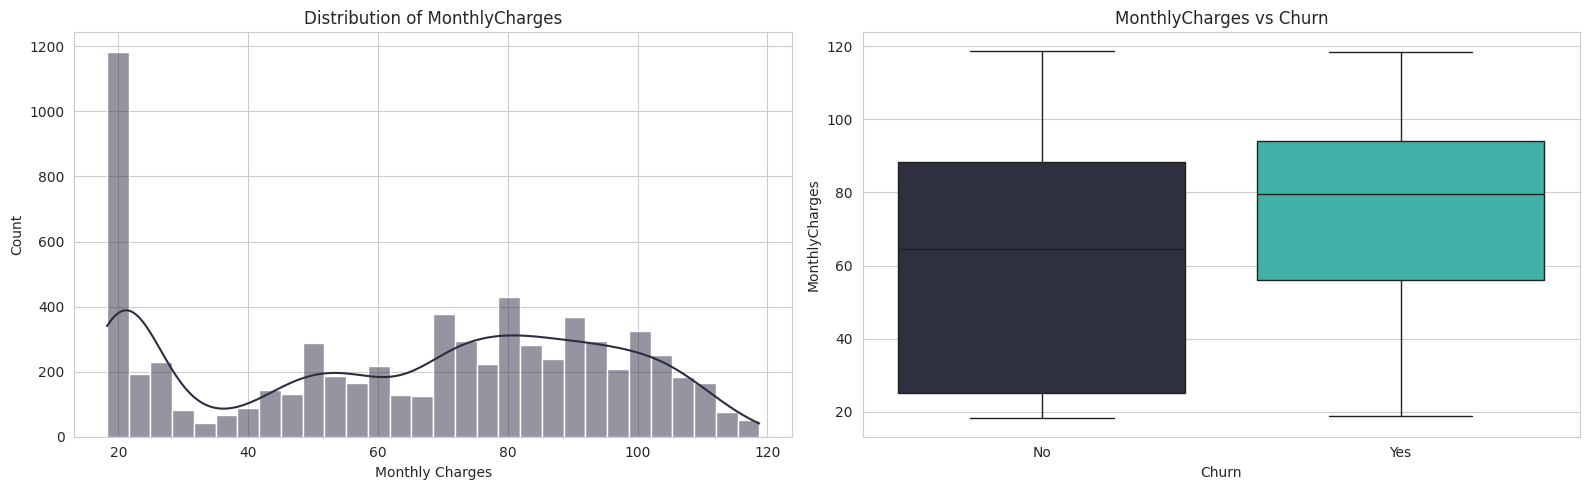

/tmp/ipykernel_2610/3049114294.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


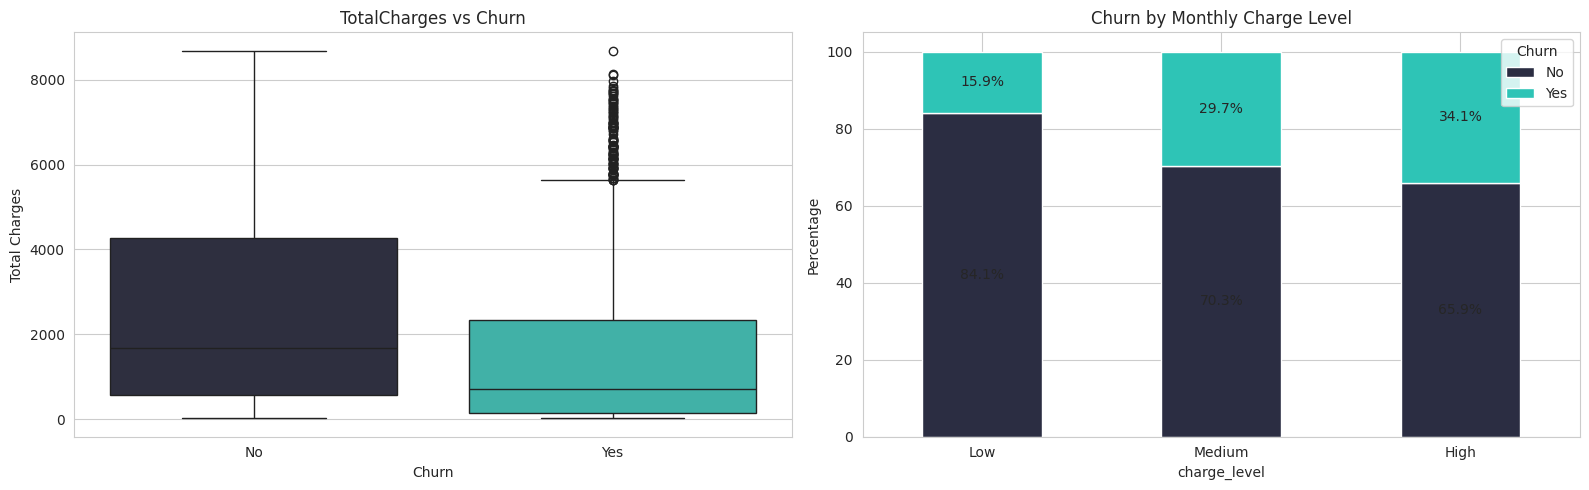

In [15]:
# ======================================================
# Analysis of Customer Charges by Churn
# ======================================================

# Safety: convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ======================================================
# Figure 1: Distribution and Boxplot of Monthly Charges
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly charges distribution
sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True,
    color=colors[0],
    ax=axes[0]
)

axes[0].set_title("Distribution of MonthlyCharges")
axes[0].set_xlabel("Monthly Charges")

# Monthly charges boxplot by churn
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df,
    palette=colors,
    ax=axes[1]
)

axes[1].set_title("MonthlyCharges vs Churn")
axes[1].set_xlabel("Churn")

plt.tight_layout()
plt.show()


# ======================================================
# Creation of Monthly Charge Levels
# ======================================================

df["charge_level"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

churn_charge = pd.crosstab(
    df["charge_level"],
    df["Churn"],
    normalize="index"
) * 100


# ======================================================
# Figure 2: Total Charges and Monthly Charge Levels
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total charges boxplot by churn
sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df,
    palette=colors,
    ax=axes[0]
)

axes[0].set_title("TotalCharges vs Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Total Charges")

# Churn analysis by monthly charge level
churn_charge.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=axes[1]
)

axes[1].set_title("Churn by Monthly Charge Level")
axes[1].set_ylabel("Percentage")
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:

    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.tight_layout()
plt.show()

## Interpretation – Analysis of Financial Variables

The analysis of financial variables helps better understand the impact of service costs on customer churn behavior.

First, the distribution of MonthlyCharges shows that customers are spread across a wide range of pricing levels, with a strong concentration around medium values. This indicates a diversity of service plans and subscriptions among customers.

Next, when examining the relationship between MonthlyCharges and churn, it appears that customers paying higher monthly charges tend to churn more frequently. This suggests that pricing may be an important disengagement factor, possibly because customers are more likely to compare competing offers when subscription costs are high.

Regarding TotalCharges, the trend is slightly different. Customers with higher total charges, which are often associated with longer customer tenure, appear to be less likely to leave the company. This can be explained by the fact that long-term customers are generally more loyal despite higher cumulative costs.

Finally, the analysis by monthly charge level confirms this pattern. Customers classified in the “high charges” category exhibit a significantly higher churn rate compared to customers with lower monthly charges. This clearly indicates that pricing is a key factor influencing customer cancellation decisions.

## 4.7 Correlation Analysis

/tmp/ipykernel_2610/331391357.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2610/331391357.py:43: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


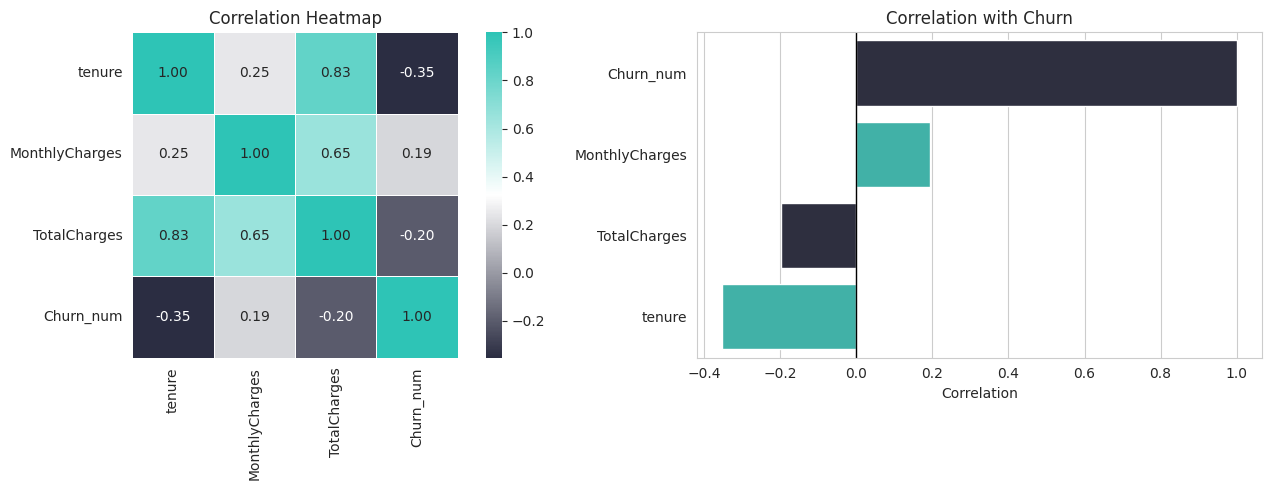

,Correlation with Churn
Churn_num,1.0%
MonthlyCharges,0.2%
TotalCharges,-0.2%
tenure,-0.4%


In [16]:
# ======================================================
# Correlation Analysis Between Numerical Variables and Churn
# ======================================================

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df["Churn_num"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

corr_df = df[num_cols + ["Churn_num"]].corr()

churn_corr = corr_df["Churn_num"].sort_values(
    ascending=False
)


# ======================================================
# Figure 1: Correlation Heatmap and Barplot
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
sns.heatmap(
    corr_df,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    ax=axes[0]
)

axes[0].set_title("Correlation Heatmap")

# Correlation barplot with churn
sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index,
    palette=colors,
    ax=axes[1]
)

axes[1].set_title("Correlation with Churn")
axes[1].set_xlabel("Correlation")
axes[1].set_ylabel("")
axes[1].axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


# ======================================================
# Styled Correlation Table
# ======================================================

corr_table = churn_corr.to_frame(
    name="Correlation with Churn"
)

display(
    style_table(
        corr_table,
        "Variable Correlations with Churn"
    )
)

## Interpretation – Correlation Analysis

The correlation analysis helps identify the numerical variables that are most strongly associated with customer churn.

First, a strong negative correlation can be observed between the variable tenure and churn. This means that the longer a customer stays with the company, the less likely they are to leave. Customer tenure is therefore a key factor in customer retention.

Next, the variable MonthlyCharges shows a positive correlation with churn, indicating that customers with higher monthly bills are slightly more likely to leave the company. This may be explained by greater price sensitivity among customers facing higher subscription costs.

Finally, the variable TotalCharges is also negatively correlated with churn, which is consistent with the fact that total charges increase with customer tenure. Loyal customers therefore accumulate higher total charges over time and are less likely to churn.

## 4.8 Analysis of Relationships Between Variables

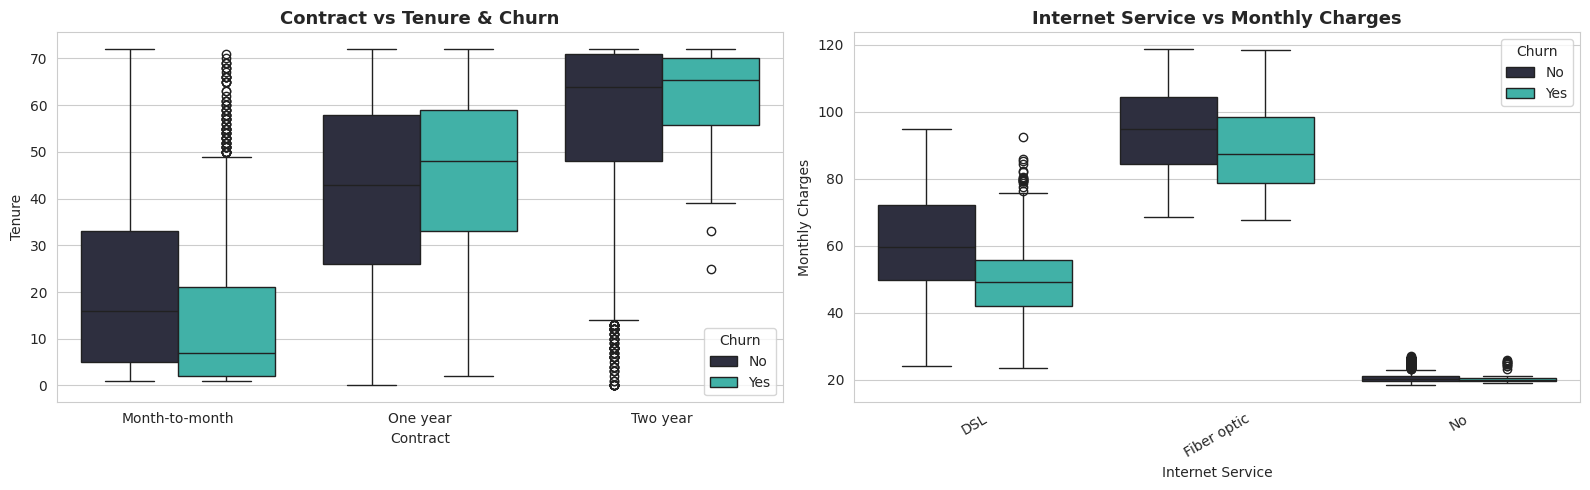

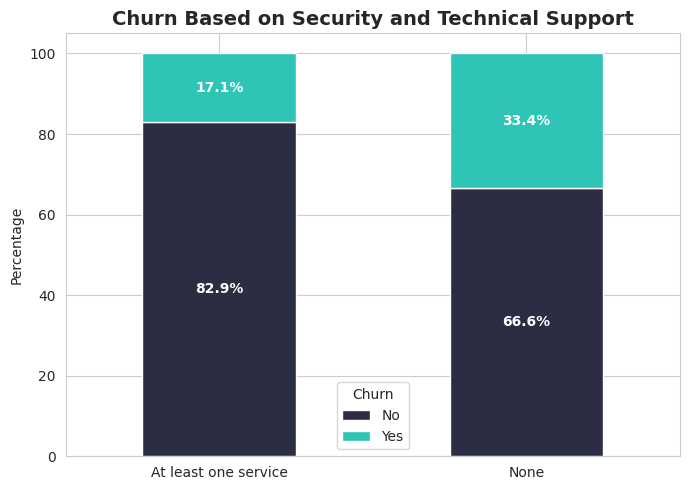

In [17]:
# ======================================================
# Creation of Combined Variables and Advanced Churn Analysis
# ======================================================

# ======================================================
# Creation of the Security_Support Variable
# ======================================================

security_support_cols = [
    "OnlineSecurity",
    "TechSupport"
]

df["Security_Support"] = df[
    security_support_cols
].apply(
    lambda x:
    "None"
    if (
        x.isin(["No", "No internet service"])
    ).all()
    else "At least one service",
    axis=1
)

# Churn proportion table
churn_sec = pd.crosstab(
    df["Security_Support"],
    df["Churn"],
    normalize="index"
) * 100


# ======================================================
# Cross-Analysis Dashboard
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ------------------------------------------------------
# Contract, Tenure, and Churn
# ------------------------------------------------------

sns.boxplot(
    x="Contract",
    y="tenure",
    hue="Churn",
    data=df,
    palette=colors,
    ax=axes[0]
)

axes[0].set_title(
    "Contract vs Tenure & Churn",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Contract")
axes[0].set_ylabel("Tenure")

axes[0].legend(
    title="Churn"
)

# ------------------------------------------------------
# Internet Service and Monthly Charges
# ------------------------------------------------------

sns.boxplot(
    x="InternetService",
    y="MonthlyCharges",
    hue="Churn",
    data=df,
    palette=colors,
    ax=axes[1]
)

axes[1].set_title(
    "Internet Service vs Monthly Charges",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Monthly Charges")

axes[1].tick_params(
    axis="x",
    rotation=30
)

axes[1].legend(
    title="Churn"
)

plt.tight_layout()
plt.show()


# ======================================================
# Churn Analysis Based on Security and Technical Support
# ======================================================

ax = churn_sec.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(7, 5)
)

plt.title(
    "Churn Based on Security and Technical Support",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Percentage")
plt.xlabel("")

plt.xticks(rotation=0)

# Display percentages
for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

plt.legend(title="Churn")

plt.tight_layout()
plt.show()

## Interpretation – Analysis of Relationships Between Variables

This analysis explores the combined effect of multiple variables on customer churn in order to better understand customer behavior.

First, the relationship between contract type and customer tenure shows that customers with month-to-month contracts generally have lower tenure and exhibit higher churn rates. In contrast, customers with long-term contracts tend to have greater tenure and stronger loyalty. This confirms that contractual commitment plays a major role in customer retention.

Next, the analysis of monthly charges according to internet service type reveals that customers using fiber optic internet usually pay higher monthly charges and also present higher churn rates. Customers using DSL or having no internet service appear to be more stable. This may indicate that fiber optic customers have higher expectations or greater price sensitivity.

Finally, the combined analysis of security and technical support services highlights an important behavioral difference. Customers without any of these services show a significantly higher churn rate compared to customers having at least one support or security service. This suggests that assistance and protection services contribute to improving customer satisfaction and loyalty.

##  4.9 Key Insights from the Exploratory Data Analysis (EDA)

The exploratory data analysis made it possible to identify several factors strongly associated with customer churn. The results show that customer departure is not driven by a single variable, but rather by a combination of behavioral, financial, and contractual factors.

Customer tenure appears to be one of the most important factors. New customers exhibit a much higher churn rate compared to long-term customers. This indicates that the first months of subscription represent a critical period during which customers are more likely to leave the company.

The contract type also plays a major role. Customers with month-to-month contracts show significantly higher churn rates than those subscribed to one-year or two-year contracts. Long-term contracts therefore seem to strongly improve customer retention.

Financial variables also have an important impact. Customers with high MonthlyCharges tend to churn more frequently. This suggests that some customers are highly price-sensitive and may leave the company when they perceive the service cost as too high relative to the value received.

The analysis of subscribed services shows that the absence of services such as OnlineSecurity and TechSupport is associated with higher churn risk. Conversely, customers benefiting from these services appear to be more satisfied and more loyal. These services therefore represent important elements of the customer experience.

Finally, certain payment methods, especially Electronic Check, are associated with higher churn rates. This may reflect customer profiles that are less stable or less engaged with the company.

---

## Most Influential Variables on Churn

The analyses performed throughout the EDA highlight the following variables as the most influential factors explaining customer churn:

- tenure  
- Contract  
- MonthlyCharges  
- OnlineSecurity  
- TechSupport  
- PaymentMethod  

These variables reflect several dimensions of customer behavior:

- customer engagement and loyalty,  
- price sensitivity,  
- perceived service quality,  
- and the overall stability of the customer relationship.

---

## Impact on Future Feature Engineering

The results obtained during the EDA also provide guidance for the next stages of data preparation and feature engineering.

Several transformations can be considered to improve the performance of future Machine Learning models:

- creation of tenure groups to better distinguish new customers from loyal customers;  
- combination of service-related variables to build global indicators of satisfaction or protection;  
- transformation of contractual and financial variables into more representative risk categories;  
- creation of interaction features between variables, such as:
  - tenure + Contract  
  - MonthlyCharges + InternetService  
  - OnlineSecurity + TechSupport  

The EDA also shows that several categorical variables will require appropriate encoding before model training.

These observations are important because they help identify which variables should be emphasized in future predictive models.

# 5. Feature Engineering

## 5.1 Feature Preparation

In [18]:
# =========================================================
# Synthèse de la préparation des données
# =========================================================

# =========================================================
# Tableaux de synthèse
# =========================================================

# 1. Dimensions
shape_df = pd.DataFrame({
    "Information": [
        "Dimensions initiales",
        "Après suppression NA",
        "Dimensions finales"
    ],
    "Valeur": [
        "(7043, 21)",
        "(7032, 21)",
        "(7032, 21)"
    ]
})

# 2. Type TotalCharges
dtype_df = pd.DataFrame({
    "Variable": ["TotalCharges"],
    "Type après conversion": ["float64"]
})

# 3. Valeurs manquantes
missing_df = pd.DataFrame({
    "Variable": ["TotalCharges"],
    "Missing Values": [11],
    "Missing %": [0.16]
})

# 4. Doublons
duplicates_df = pd.DataFrame({
    "Indicateur": ["Nombre de doublons"],
    "Valeur": [0]
})

# 5. Répartition variables
variables_df = pd.DataFrame({
    "Type": [
        "Variables numériques",
        "Variables catégorielles"
    ],
    "Nombre": [4, 17]
})

# 6. Résumé final
summary_df = pd.DataFrame({
    "Résumé": [
        "Dataset prêt pour le Feature Engineering",
        "Dimensions finales",
        "Variables numériques",
        "Variables catégorielles"
    ],
    "Valeur": [
        "Oui",
        "(7032, 21)",
        "4",
        "17"
    ]
})


# =========================================================
# Fonction de style des tableaux
# =========================================================

def style_table(df, title):

    return (
        df.style
        .set_caption(title)
        .background_gradient(cmap=custom_cmap)
        .set_properties(**{
            "text-align": "center",
            "border": f"1px solid {colors[0]}",
            "font-size": "14px"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("color", colors[0]),
                    ("font-size", "18px"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("margin-bottom", "10px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", colors[0]),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("font-size", "14px")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("width", "100%")
                ]
            }
        ])
    )


# =========================================================
# Affichage horizontal 1
# =========================================================

html1 = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1;">
{style_table(shape_df, "Dimensions du Dataset").to_html()}
</div>

<div style="flex:1;">
{style_table(dtype_df, "Type de TotalCharges").to_html()}
</div>

</div>
"""

display(HTML(html1))


# =========================================================
# Affichage horizontal 2
# =========================================================

html2 = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1;">
{style_table(missing_df, "Valeurs Manquantes").to_html()}
</div>

<div style="flex:1;">
{style_table(duplicates_df, "Vérification des Doublons").to_html()}
</div>

</div>
"""

display(HTML(html2))


# =========================================================
# Affichage horizontal 3
# =========================================================

html3 = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1;">
{style_table(variables_df, "Répartition des Variables").to_html()}
</div>

<div style="flex:1;">
{style_table(summary_df, "Résumé Préparation des Données").to_html()}
</div>

</div>
"""

display(HTML(html3))

,Information,Valeur
0,Dimensions initiales,"(7043, 21)"
1,Après suppression NA,"(7032, 21)"
2,Dimensions finales,"(7032, 21)"
,Variable,Type après conversion
0,TotalCharges,float64


,Type,Nombre
0,Variables numériques,4
1,Variables catégorielles,17
,Résumé,Valeur
0,Dataset prêt pour le Feature Engineering,Oui
1,Dimensions finales,"(7032, 21)"
2,Variables numériques,4
3,Variables catégorielles,17


## Interpretation – Feature Preparation

This data preparation step ensured the quality and consistency of the dataset before feature engineering and model development.

The variable TotalCharges was converted into a numerical format to enable statistical analysis and future Machine Learning processing. The missing values detected in this variable were removed because they mainly corresponded to very recent customers who did not yet have complete billing information.

The duplicate check confirmed that no duplicated rows were present in the dataset, which validates the uniqueness of customer observations.

Finally, numerical and categorical variables were separated in order to facilitate the next transformation steps, particularly categorical variable encoding and numerical feature scaling.

## 5.2 Encoding Variables and Train/Test Split

In [19]:
# =========================================================
# Variable Encoding and Train/Test Split
# =========================================================

df_model = df.copy()

if "customerID" in df_model.columns:
    df_model = df_model.drop("customerID", axis=1)

le_target = LabelEncoder()

df_model["Churn"] = le_target.fit_transform(
    df_model["Churn"]
)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

le = LabelEncoder()

for col in binary_cols:

    X_train[col] = le.fit_transform(
        X_train[col]
    )

    X_test[col] = le.transform(
        X_test[col]
    )

multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

X_train = pd.get_dummies(
    X_train,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

encoding_summary = pd.DataFrame({
    "Information": [
        "Split performed before encoding",
        "Binary variables encoded",
        "Multi-categorical variables encoded",
        "Train/test alignment",
        "Removed variable",
        "Final number of features"
    ],
    "Value": [
        "Yes",
        len(binary_cols),
        len(multi_cols),
        "OK",
        "customerID",
        X_train.shape[1]
    ]
})

preview_df = X_train.head()

display(
    style_table(
        encoding_summary,
        "Encoding Summary"
    )
)

display(
    style_table(
        preview_df,
        "Training Dataset Preview"
    )
)

,Information,Value
0,Split performed before encoding,Yes
1,Binary variables encoded,5
2,Multi-categorical variables encoded,10
3,Train/test alignment,OK
4,Removed variable,customerID
5,Final number of features,34


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,tenure_group,charge_level,Churn_num,Security_Support,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,35,0,0,49.200000,1701.650000,24-36,Low,0,None,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
3151,1,0,1,1,15,1,0,75.100000,1151.550000,12-24,Medium,0,At least one service,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4860,1,0,1,1,13,0,0,40.550000,590.350000,12-24,Low,0,At least one service,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1
3867,0,0,1,0,26,1,1,73.500000,1905.700000,24-36,Medium,0,None,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,1,0,0
3810,1,0,1,1,1,1,0,44.550000,44.550000,0-6,Low,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## Interpretation – Variable Encoding and Train/Test Split

This encoding step transformed categorical variables into numerical variables so they could be processed by Machine Learning algorithms.

Binary variables were converted using Label Encoding, while variables containing multiple categories were transformed using One-Hot Encoding in order to avoid introducing an artificial order between categories.

The variable customerID was removed because it only represents a customer identifier and does not provide useful information for churn prediction.

After the encoding process, the dataset became fully numerical and ready for the next stages of feature engineering and predictive modeling.

## 5.3 Creation of New Explanatory Features

In [20]:
# =========================================================
# Creation of New Explanatory Features
# =========================================================

X_train = X_train.copy()
X_test = X_test.copy()

def tenure_group(x):

    if x <= 12:
        return 0

    elif x <= 48:
        return 1

    else:
        return 2


X_train["tenure_group"] = X_train["tenure"].apply(
    tenure_group
)

X_test["tenure_group"] = X_test["tenure"].apply(
    tenure_group
)


def engagement_level(row):

    if row["tenure"] <= 12:
        return 0

    elif row["tenure"] <= 48:
        return 1

    else:
        return 2


X_train["Engagement_Level"] = X_train.apply(
    engagement_level,
    axis=1
)

X_test["Engagement_Level"] = X_test.apply(
    engagement_level,
    axis=1
)


security_cols = [
    col for col in X_train.columns
    if (
        "OnlineSecurity_Yes" in col
        or "OnlineBackup_Yes" in col
        or "DeviceProtection_Yes" in col
        or "TechSupport_Yes" in col
    )
]

X_train["Security_Services_Count"] = X_train[
    security_cols
].sum(axis=1)

X_test["Security_Services_Count"] = X_test[
    security_cols
].sum(axis=1)


def charge_level(x):

    if x < 35:
        return 0

    elif x < 70:
        return 1

    else:
        return 2


X_train["Charge_Level"] = X_train["MonthlyCharges"].apply(
    charge_level
)

X_test["Charge_Level"] = X_test["MonthlyCharges"].apply(
    charge_level
)


service_cols = [
    col for col in X_train.columns
    if (
        col == "PhoneService"
        or "MultipleLines_Yes" in col
        or "OnlineSecurity_Yes" in col
        or "OnlineBackup_Yes" in col
        or "DeviceProtection_Yes" in col
        or "TechSupport_Yes" in col
        or "StreamingTV_Yes" in col
        or "StreamingMovies_Yes" in col
    )
]

X_train["Total_Services"] = X_train[
    service_cols
].sum(axis=1)

X_test["Total_Services"] = X_test[
    service_cols
].sum(axis=1)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

preview_features = X_train[
    [
        "tenure",
        "tenure_group",
        "Engagement_Level",
        "Security_Services_Count",
        "Charge_Level",
        "Total_Services"
    ]
].head()

display(
    style_table(
        preview_features,
        "Created Features Preview"
    )
)

,tenure,tenure_group,Engagement_Level,Security_Services_Count,Charge_Level,Total_Services
3738,35,1,1,1,1,3
3151,15,1,1,1,2,2
4860,13,1,1,3,1,3
3867,26,1,1,2,2,5
3810,1,0,0,0,1,1


## Interpretation – Feature Engineering

This feature engineering step aimed to create new variables capable of better capturing customer behavior and improving the predictive performance of the Machine Learning models.

First, the variable `tenure_group` was created to classify customers according to their level of seniority. This transformation helps distinguish new customers, medium-term customers, and loyal customers more clearly than using the raw tenure variable alone. Since the EDA showed that churn is much higher during the first months, this grouping can help the model identify high-risk profiles more effectively.

Next, the variable `Engagement_Level` was introduced to represent the overall customer engagement with the company. Customers with longer tenure are considered more engaged and therefore less likely to churn. This feature reinforces the importance of customer loyalty identified during the exploratory analysis.

The variable `Security_Services_Count` measures the number of protection and support services subscribed to by each customer, such as OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport. The EDA revealed that customers without these services churn more frequently. This new feature therefore summarizes the overall level of customer protection and support in a single indicator.

The variable `Charge_Level` was created to group customers according to their monthly charges. Since customers with higher monthly costs showed a higher churn rate during the analysis, this categorization allows the model to better capture customer price sensitivity.

Finally, the variable `Total_Services` measures the total number of subscribed services. Customers using multiple services are generally more engaged with the company and may be less likely to leave. This feature therefore represents the overall intensity of product usage.

Overall, these engineered features allow the dataset to better reflect customer behavior, engagement, service adoption, and financial risk factors. They are expected to improve the ability of the predictive models to identify customers at high risk of churn.

## 5.4 Feature Interactions

In [21]:
# =========================================================
# Creation of Interaction Features
# =========================================================

X_train = X_train.copy()
X_test = X_test.copy()

# =========================================================
# A. Interaction Between Tenure and Contract
# =========================================================

contract_col = "Contract_Two year"

if contract_col in X_train.columns:

    X_train["Tenure_Contract_Interaction"] = (
        X_train["tenure"] * X_train[contract_col]
    )

    X_test["Tenure_Contract_Interaction"] = (
        X_test["tenure"] * X_test[contract_col]
    )

else:

    X_train["Tenure_Contract_Interaction"] = X_train["tenure"]
    X_test["Tenure_Contract_Interaction"] = X_test["tenure"]


# =========================================================
# B. Interaction Between Monthly Charges and Internet Service
# =========================================================

fiber_col = "InternetService_Fiber optic"

if fiber_col in X_train.columns:

    X_train["Charges_Internet_Interaction"] = (
        X_train["MonthlyCharges"] * X_train[fiber_col]
    )

    X_test["Charges_Internet_Interaction"] = (
        X_test["MonthlyCharges"] * X_test[fiber_col]
    )

else:

    X_train["Charges_Internet_Interaction"] = X_train["MonthlyCharges"]
    X_test["Charges_Internet_Interaction"] = X_test["MonthlyCharges"]


# =========================================================
# C. Interaction Between Security and Technical Support
# =========================================================

security_support_cols = [
    col for col in X_train.columns
    if (
        "OnlineSecurity_Yes" in col
        or "TechSupport_Yes" in col
    )
]

X_train["Security_Support_Interaction"] = X_train[
    security_support_cols
].sum(axis=1)

X_test["Security_Support_Interaction"] = X_test[
    security_support_cols
].sum(axis=1)


# =========================================================
# Final Train/Test Alignment
# =========================================================

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)


# =========================================================
# Interaction Features Preview
# =========================================================

interaction_preview = X_train[
    [
        "tenure",
        "MonthlyCharges",
        "Tenure_Contract_Interaction",
        "Charges_Internet_Interaction",
        "Security_Support_Interaction"
    ]
].head()

display(
    style_table(
        interaction_preview,
        "Feature Interactions Preview"
    )
)

,tenure,MonthlyCharges,Tenure_Contract_Interaction,Charges_Internet_Interaction,Security_Support_Interaction
3738,35,49.200000,0,0.000000,0
3151,15,75.100000,0,75.100000,1
4860,13,40.550000,13,0.000000,2
3867,26,73.500000,26,0.000000,0
3810,1,44.550000,0,0.000000,0


## Interpretation – Feature Interactions

This step focused on creating interaction features in order to capture more complex relationships between variables and improve the predictive power of the Machine Learning models.

First, the variable `Tenure_Contract_Interaction` combines customer tenure with the long-term contract variable. The objective is to better represent customer loyalty behavior. Customers with both a long tenure and a long-term contract are generally more stable and less likely to churn. This interaction allows the model to capture the combined effect of customer loyalty and contractual commitment.

Next, the variable `Charges_Internet_Interaction` combines monthly charges with fiber optic internet service usage. The exploratory analysis showed that fiber optic customers often have higher monthly charges and also present a higher churn rate. This interaction helps the model identify customers who may be sensitive to the price-performance balance of premium internet services.

Finally, the variable `Security_Support_Interaction` combines the presence of OnlineSecurity and TechSupport services. Customers using these services are generally better supported and more protected, which tends to reduce churn. This feature therefore represents the overall level of customer assistance and service protection.

Overall, these interaction features help the model better understand how multiple customer characteristics work together to influence churn behavior. Instead of analyzing variables independently, the model can now capture more realistic customer patterns and potentially improve prediction accuracy.

## 5.5 Numerical Feature Scaling

In [22]:
# =========================================================
# Numerical Feature Scaling
# =========================================================

X_train = X_train.copy()
X_test = X_test.copy()

# =========================================================
# Numerical Variables
# =========================================================

num_cols = [
    "MonthlyCharges",
    "TotalCharges",
    "tenure"
]

# =========================================================
# Scaler Initialization
# =========================================================

scaler = StandardScaler()

# =========================================================
# Scaling on the Training Dataset
# =========================================================

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

# =========================================================
# Transformation of the Test Dataset
# =========================================================

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

# =========================================================
# Standardized Numerical Variables Preview
# =========================================================

display(
    style_table(
        X_train[num_cols].head(),
        "Numerical Variables Preview (TRAIN - StandardScaler)"
    )
)

,MonthlyCharges,TotalCharges,tenure
3738,-0.521976,-0.263695,0.102371
3151,0.337478,-0.505076,-0.711743
4860,-0.809013,-0.751328,-0.793155
3867,0.284384,-0.174159,-0.263980
3810,-0.676279,-0.990822,-1.281624


## Interpretation – Numerical Feature Scaling

In this step, numerical variables were standardized in order to improve the performance of the Machine Learning models and ensure better consistency between features.

The variables `MonthlyCharges`, `TotalCharges`, and `tenure` were scaled using the `StandardScaler` method. This transformation centers the variables around 0 and reduces them according to their standard deviation. As a result, positive values represent observations above the average, while negative values correspond to observations below the average.

For example, a value such as `MonthlyCharges = -1.16` indicates that the customer pays monthly charges below the dataset average. Similarly, `tenure = -1.28` represents a relatively new customer compared to the overall customer population. On the other hand, values close to 0 indicate customers whose characteristics are near the average.

This scaling process ensures that all numerical variables are placed on the same scale, preventing variables with larger magnitudes from dominating the model. Standardization is particularly important for algorithms sensitive to feature magnitude and distance, such as Logistic Regression and gradient-based models.

Overall, this step makes the dataset more homogeneous and contributes to improving the stability, convergence, and predictive performance of the churn prediction models.

## 5.6 Correlation Analysis with the Target Variable

In [23]:
# =========================================================
# Correlation Analysis with the Target Variable
# =========================================================

# =========================================================
# Creation of the Full Training Dataset
# =========================================================

train_data = X_train.copy()

# Add target variable
train_data["Churn"] = y_train.values

# Explicit integer conversion
train_data["Churn"] = train_data["Churn"].astype(int)

# =========================================================
# Correlation Calculation
# =========================================================

corr_matrix = train_data.corr(
    numeric_only=True
)

correlation = corr_matrix["Churn"].sort_values(
    ascending=False
)

# =========================================================
# Correlation Table
# =========================================================

corr_df = pd.DataFrame({
    "Feature": correlation.index,
    "Correlation_with_Churn": correlation.values
})

# =========================================================
# Display Results
# =========================================================

display(
    style_table(
        corr_df,
        "Feature Correlation with Churn (TRAIN Only)"
    )
)

,Feature,Correlation_with_Churn
0,Churn,1.000000
1,Churn_num,1.000000
2,InternetService_Fiber optic,0.312656
3,PaymentMethod_Electronic check,0.309214
4,Charges_Internet_Interaction,0.277548
5,Charge_Level,0.233366
6,MonthlyCharges,0.198040
7,PaperlessBilling,0.197981
8,SeniorCitizen,0.145599
9,StreamingTV_Yes,0.072397


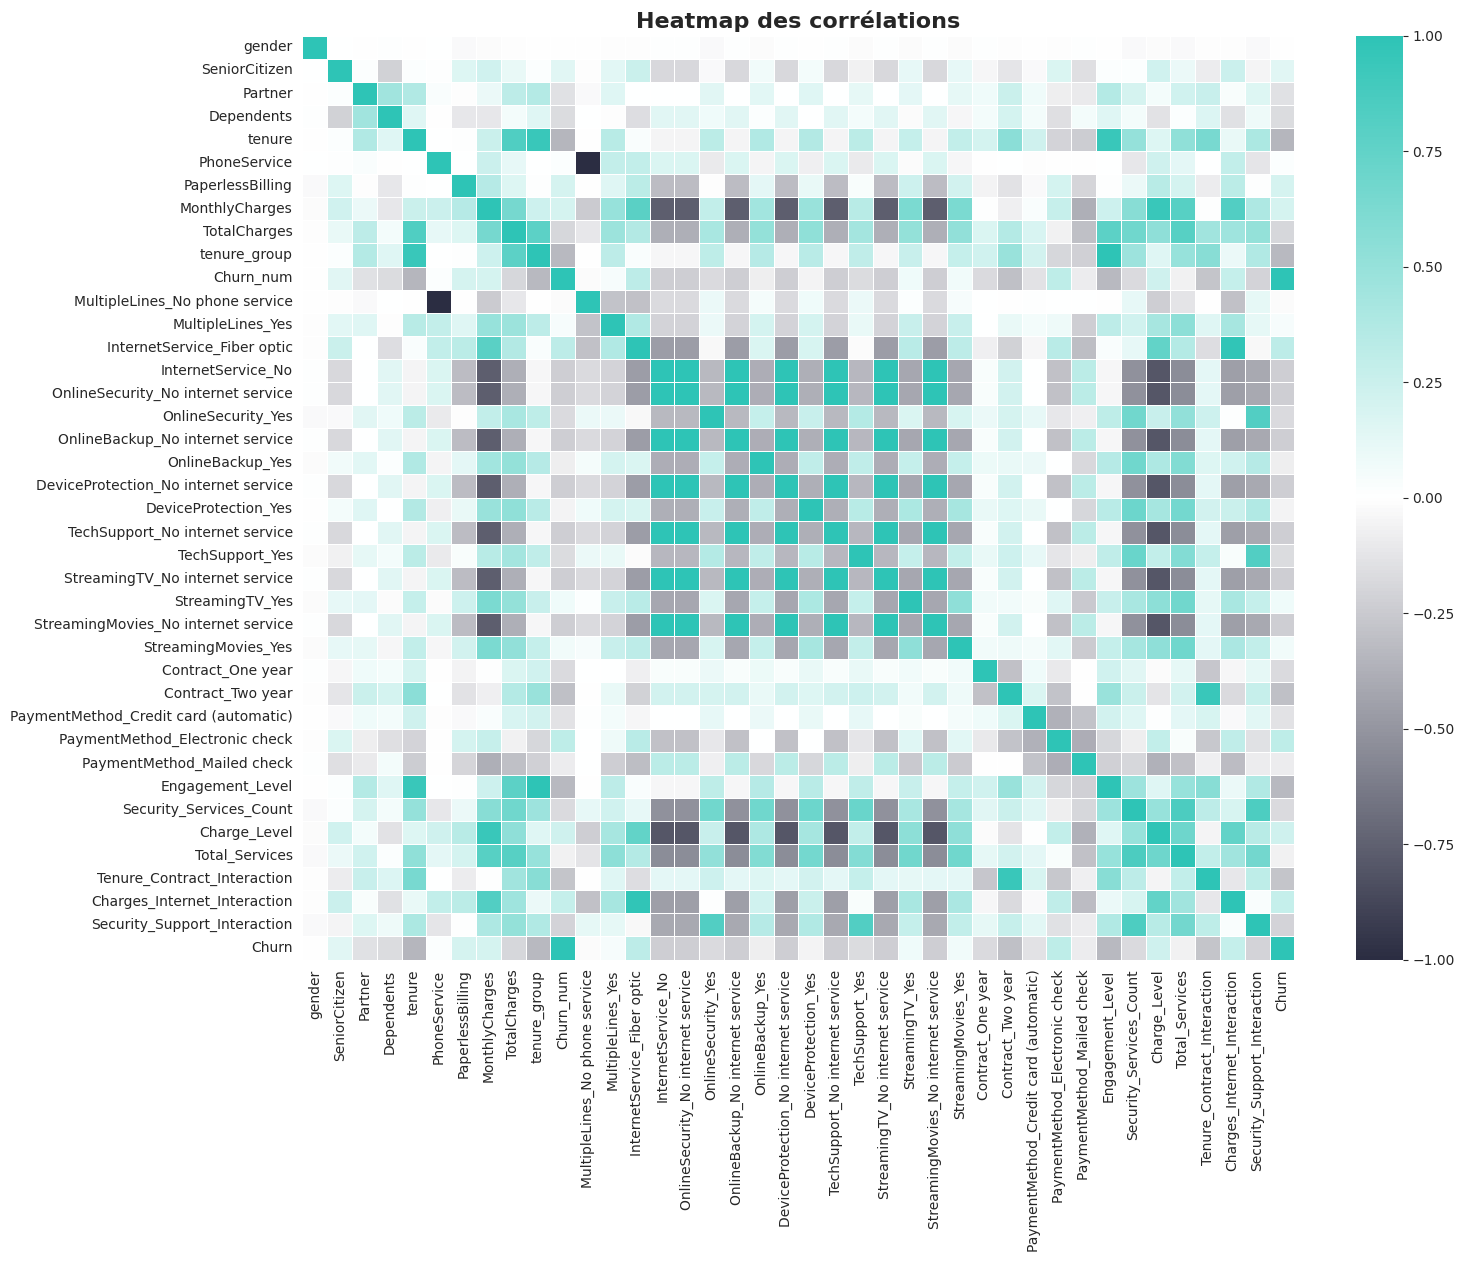

In [24]:
# =========================================================
# Correlation Heatmap
# =========================================================

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap=custom_cmap,
    center=0,
    linewidths=0.5
)

plt.title(
    "Heatmap des corrélations",
    fontsize=16,
    fontweight="bold"
)

plt.show()

## Interpretation – Correlation Analysis with the Target Variable

This analysis was performed to better understand the relationships between the explanatory variables and the target variable `Churn` within the training dataset.

The correlation matrix measures both the direction and strength of the linear relationship between variables. Positive correlations indicate that the feature is associated with a higher probability of churn, while negative correlations indicate that the feature is associated with customer loyalty and retention.

The results show that some variables are strongly associated with churn. Features related to monthly contracts, high monthly charges, and fiber optic internet service tend to present positive correlations with churn. This means that customers with these characteristics are more likely to leave the company.

In contrast, variables such as `tenure`, long-term contracts, and support or security services generally show negative correlations with churn. These features are associated with more stable and loyal customers who are less likely to cancel their subscriptions.

The heatmap also highlights relationships between explanatory variables themselves. Some features appear to be moderately correlated because they represent similar aspects of customer behavior or service usage. For example, variables related to security services and technical support may evolve together.

Overall, this analysis confirms the main insights discovered during the exploratory data analysis phase. Customer engagement, contract duration, pricing, and service quality remain the most important dimensions influencing churn behavior. These findings are valuable for understanding model behavior and identifying the most relevant predictors for churn prediction.

## 5.7 Feature Selection with Mutual Information

In [25]:
# =========================================================
# Feature Selection Using Mutual Information
# =========================================================

# =========================================================
# Work on Train/Test Only
# =========================================================

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# =========================================================
# Train/Test Alignment
# =========================================================

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# =========================================================
# Forced Numeric Conversion
# =========================================================

X_train_encoded = X_train_encoded.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test_encoded = X_test_encoded.apply(
    pd.to_numeric,
    errors="coerce"
)

# =========================================================
# Missing Values Handling
# =========================================================

X_train_encoded = X_train_encoded.fillna(0)
X_test_encoded = X_test_encoded.fillna(0)

# =========================================================
# Missing Values Verification
# =========================================================

print("NaN TRAIN :", X_train_encoded.isna().sum().sum())
print("NaN TEST :", X_test_encoded.isna().sum().sum())

# =========================================================
# Removal of Potential Data Leakage
# =========================================================

if "Churn_num" in X_train_encoded.columns:

    X_train_encoded = X_train_encoded.drop(
        columns=["Churn_num"]
    )

    X_test_encoded = X_test_encoded.drop(
        columns=["Churn_num"]
    )

if "Churn" in X_train_encoded.columns:

    X_train_encoded = X_train_encoded.drop(
        columns=["Churn"]
    )

    X_test_encoded = X_test_encoded.drop(
        columns=["Churn"]
    )

# =========================================================
# Mutual Information Calculation
# =========================================================

mi = mutual_info_classif(
    X_train_encoded,
    y_train,
    random_state=42
)

# =========================================================
# Mutual Information Scores Table
# =========================================================

mi_df = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Mutual_Information": mi
}).sort_values(
    by="Mutual_Information",
    ascending=False
)

# =========================================================
# Display Results
# =========================================================

display(
    style_table(
        mi_df,
        "Mutual Information with Churn"
    )
)

NaN TRAIN : 0
NaN TEST : 0


,Feature,Mutual_Information
4,tenure,0.065823
33,Engagement_Level,0.063231
38,Charges_Internet_Interaction,0.061383
29,Contract_Two year,0.059346
31,PaymentMethod_Electronic check,0.055246
9,tenure_group,0.054274
37,Tenure_Contract_Interaction,0.054139
7,MonthlyCharges,0.049491
14,InternetService_Fiber optic,0.049327
24,StreamingTV_No internet service,0.043799


## Interpretation – Feature Selection with Mutual Information

This step was performed to identify the most informative variables for predicting customer churn using the Mutual Information technique.

Mutual Information measures how much information a feature provides about the target variable `Churn`. Unlike simple correlation analysis, this method can capture both linear and non-linear relationships between variables and the target. A higher Mutual Information score indicates that the feature is more useful for predicting churn.

Before computing the scores, the training and test datasets were carefully aligned to ensure that both datasets contained the same variables. All features were also converted into numerical format, and missing values were handled to guarantee compatibility with the algorithm.

Potential data leakage variables such as `Churn` or `Churn_num` were removed before the analysis. This is an important step because including target-related variables could artificially inflate the importance scores and lead to unreliable model performance.

The results highlight the variables that contribute the most to churn prediction. Features related to customer loyalty (`tenure`), contract type, monthly charges, internet services, and customer support generally obtain the highest Mutual Information scores. This confirms the conclusions obtained during the exploratory data analysis and correlation analysis phases.

Compared to correlation analysis, Mutual Information provides a more robust understanding of feature importance because it is capable of detecting more complex dependencies between variables and churn behavior.

Overall, this step helps identify the most relevant predictors, reduce noise in the dataset, and improve the interpretability and performance of the future Machine Learning models.

## 5.8 Feature Selection with Random Forest

In [26]:
# =========================================================
# Feature Selection Using Random Forest
# =========================================================

# =========================================================
# Data Copy
# =========================================================

X_train_rf = X_train_encoded.copy()
X_test_rf = X_test_encoded.copy()

# =========================================================
# Data Verification and Cleaning
# =========================================================

X_train_rf = X_train_rf.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test_rf = X_test_rf.apply(
    pd.to_numeric,
    errors="coerce"
)

X_train_rf = X_train_rf.fillna(0)
X_test_rf = X_test_rf.fillna(0)

# =========================================================
# Removal of Potential Data Leakage
# =========================================================

for col in ["Churn", "Churn_num"]:

    if col in X_train_rf.columns:

        X_train_rf = X_train_rf.drop(
            columns=[col]
        )

    if col in X_test_rf.columns:

        X_test_rf = X_test_rf.drop(
            columns=[col]
        )

# =========================================================
# Random Forest Model
# =========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_rf,
    y_train
)

# =========================================================
# Feature Importance
# =========================================================

rf_importance = pd.DataFrame({
    "Feature": X_train_rf.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

# =========================================================
# Display Results
# =========================================================

display(
    style_table(
        rf_importance,
        "Random Forest Feature Importance"
    )
)

,Feature,Importance
8,TotalCharges,0.143481
7,MonthlyCharges,0.127345
4,tenure,0.126120
38,Charges_Internet_Interaction,0.091934
9,tenure_group,0.033109
31,PaymentMethod_Electronic check,0.031205
34,Security_Services_Count,0.028722
36,Total_Services,0.028634
33,Engagement_Level,0.028469
14,InternetService_Fiber optic,0.026048


## Interpretation – Feature Selection with Random Forest

This step aimed to identify the most important variables for churn prediction using a Random Forest model.

Random Forest is an ensemble Machine Learning algorithm based on multiple decision trees. One of its advantages is its ability to automatically estimate feature importance by measuring how much each variable contributes to improving prediction accuracy during the tree construction process.

Before training the model, all variables were converted into numerical format and missing values were handled to ensure clean and consistent data. Potential leakage variables such as `Churn` and `Churn_num` were also removed to avoid biased importance scores.

The results show that some variables contribute much more strongly to churn prediction than others. Features related to customer loyalty (`tenure`), monthly charges, contract type, internet services, and support services generally appear among the most important predictors.

The Random Forest importance scores confirm many findings from the exploratory data analysis and Mutual Information analysis. In particular, customer engagement, pricing, and service quality remain the main dimensions influencing churn behavior.

Unlike correlation analysis, Random Forest can capture complex non-linear relationships and interactions between variables. This makes the feature importance analysis more robust and more representative of real customer behavior.

Overall, this step helps identify the variables that contribute the most to churn prediction and provides valuable insights for improving model performance and interpretability.

## 5.9 Final Feature Selection for Modeling

In [27]:
# =========================================================
# Final Feature Selection for Modeling
# =========================================================

# Target variable
target = "Churn"

# =========================================================
# Selection of the Best Features
# =========================================================

top_features = rf_importance["Feature"].head(15).tolist()

# =========================================================
# Creation of Final Train/Test Datasets
# =========================================================

df_selected_train = X_train_encoded[
    top_features
].copy()

df_selected_test = X_test_encoded[
    top_features
].copy()

# =========================================================
# Add Target Variable to the Training Dataset
# =========================================================

df_selected_train[target] = y_train.values

# =========================================================
# Final Information
# =========================================================

print("Number of selected features:", len(top_features))

display(
    style_table(
        df_selected_train.head(),
        "TRAIN Dataset with Selected Features"
    )
)

Number of selected features: 15


,TotalCharges,MonthlyCharges,tenure,Charges_Internet_Interaction,tenure_group,PaymentMethod_Electronic check,Security_Services_Count,Total_Services,Engagement_Level,InternetService_Fiber optic,gender,PaperlessBilling,Security_Support_Interaction,Partner,Tenure_Contract_Interaction,Churn
3738,-0.263695,-0.521976,0.102371,0.000000,1,1,1,3,1,0,1,0,0,0,0,0
3151,-0.505076,0.337478,-0.711743,75.100000,1,0,1,2,1,1,1,0,1,1,0,0
4860,-0.751328,-0.809013,-0.793155,0.000000,1,0,3,3,1,0,1,0,2,1,13,0
3867,-0.174159,0.284384,-0.263980,0.000000,1,0,2,5,1,0,0,1,0,1,26,0
3810,-0.990822,-0.676279,-1.281624,0.000000,0,1,0,1,0,0,1,0,0,1,0,0


## Interpretation – Final Feature Selection for Modeling

This step selects the most important features identified by the Random Forest feature importance analysis.

The top 15 variables were selected in order to keep the most relevant predictors while reducing the dimensionality of the dataset. This helps simplify the model, reduce noise, and improve interpretability.

The final training dataset contains the selected explanatory variables as well as the target variable `Churn`. The test dataset contains the same selected features but does not include the target variable, as it will be used for model evaluation.

Overall, this step prepares a cleaner and more focused dataset for the Machine Learning modeling phase.

## 5.10 Final Datasets Preparation

In [28]:
# =========================================================
# FULL DATASETS
# =========================================================

X_train_full = X_train_encoded.copy()
X_test_full = X_test_encoded.copy()

# =========================================================
# DATASETS WITH SELECTED FEATURES
# =========================================================

X_train_selected = df_selected_train.drop(
    "Churn",
    axis=1
)

X_test_selected = df_selected_test.copy()

## Interpretation – Final Datasets Preparation

At this stage, two different versions of the datasets were prepared for the modeling phase.

The first version contains the complete datasets (`X_train_full` and `X_test_full`) with all engineered and encoded features. These datasets allow the models to use the maximum amount of available information during training.

The second version contains only the selected variables identified as the most important during the feature selection process (`X_train_selected` and `X_test_selected`). These datasets are more compact and focus only on the strongest predictors of churn.

Using both approaches makes it possible to compare model performance between the full feature space and the reduced feature set. In some cases, reducing the number of variables can improve model interpretability, reduce overfitting, and simplify computations without significantly decreasing predictive performance.

Overall, this step finalizes the data preparation process and provides optimized datasets ready for Machine Learning model training and evaluation.

## 5.11 Saving Final Datasets

In [29]:
# =========================================================
# Save Final Datasets
# =========================================================

X_train_full.to_csv(
    "X_train_full.csv",
    index=False
)

X_test_full.to_csv(
    "X_test_full.csv",
    index=False
)

X_train_selected.to_csv(
    "X_train_selected.csv",
    index=False
)

X_test_selected.to_csv(
    "X_test_selected.csv",
    index=False
)

y_train.to_csv(
    "y_train.csv",
    index=False
)

y_test.to_csv(
    "y_test.csv",
    index=False
)

print("Datasets successfully saved.")

Datasets successfully saved.


## Interpretation – Saving Final Datasets

This step saves the final processed datasets in CSV format in order to preserve the results of the data preparation and feature engineering pipeline.

Saving the datasets avoids rerunning all preprocessing steps each time the notebook is executed. It also guarantees that the same clean and transformed datasets can be reused consistently for future experiments and model training.

Both the complete datasets and the selected-feature datasets were saved. This allows future comparisons between models trained on all variables and models trained only on the most important features.

The target variables `y_train` and `y_test` were also saved separately to simplify the future modeling and evaluation process.

Overall, this step finalizes the data preparation phase and creates reusable datasets ready for Machine Learning modeling, dashboard creation, deployment, and future project extensions.

## 5.12 Conclusion – Feature Engineering

The feature engineering phase played a key role in improving the quality and predictive potential of the dataset before the modeling stage.

Several transformations were applied in order to better represent customer behavior and capture the factors influencing churn. New variables related to customer engagement, service usage, pricing levels, and customer loyalty were created to enrich the dataset and provide more meaningful information to the Machine Learning models.

Interaction features were also introduced to capture more complex relationships between variables, such as the combined effect of contract type and customer tenure or the relationship between internet services and monthly charges. These interactions help the models better understand real customer behavior patterns.

In addition, numerical variables were standardized to ensure consistent scales across features and improve the performance of algorithms sensitive to variable magnitude.

Different feature selection techniques, including correlation analysis, Mutual Information, and Random Forest importance, were used to identify the most relevant predictors of churn. These analyses confirmed that variables such as tenure, contract type, monthly charges, internet services, and customer support are among the strongest drivers of customer churn.

Finally, optimized training and testing datasets were created and saved for future modeling, evaluation, and deployment tasks.

Overall, the feature engineering process significantly improved the structure, interpretability, and predictive power of the dataset, creating a strong foundation for building reliable churn prediction models.

# 6. Machine Learning Modeling

## 6.1 Machine Learning Data Preparation

In [30]:
# =========================================================
# Final Dataset Preparation for Modeling
# =========================================================

# =========================================================
# Final Dataset from Feature Selection
# =========================================================

X_train_final = df_selected_train.drop(
    columns=["Churn"]
)

y_train_final = df_selected_train["Churn"]

X_test_final = df_selected_test.copy()

# =========================================================
# Train/Test Columns Alignment
# =========================================================

X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

# =========================================================
# Final Data Cleaning
# =========================================================

X_train_final = X_train_final.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

X_test_final = X_test_final.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)
# =========================================================
# Save Final Transformed Dataset
# =========================================================

X_train_final.to_csv(
    "customer_churn_transformed.csv",
    index=False
)

print("Final transformed dataset successfully saved.")

Final transformed dataset successfully saved.


## Interpretation – Machine Learning Data Preparation

This step finalizes the preparation of the datasets before training the Machine Learning models.

The training dataset was created using the selected features identified during the feature selection process. The target variable `Churn` was separated from the explanatory variables in order to clearly distinguish inputs and outputs for the modeling phase.

The train and test datasets were then aligned to ensure that both datasets contain exactly the same variables in the same order. This step is essential because Machine Learning models require identical feature structures during both training and prediction.

A final cleaning process was also applied by converting all variables into numerical format and replacing potential missing values with zeros. This guarantees full compatibility with the Machine Learning algorithms and prevents execution errors during model training.

Overall, this step ensures that the datasets are clean, consistent, and fully ready for predictive modeling and evaluation.

## 6.2 Model Training and Evaluation Before SMOTE

In [31]:
# =========================================================
# Model Training and Evaluation Before SMOTE
# =========================================================

# =========================================================
# 1. Logistic Regression
# =========================================================

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_final,
    y_train_final
)

y_pred_log = log_model.predict(
    X_test_final
)


# =========================================================
# 2. Random Forest
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_final,
    y_train_final
)

y_pred_rf = rf_model.predict(
    X_test_final
)


# =========================================================
# 3. XGBoost
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_final,
    y_train_final
)

y_pred_xgb = xgb_model.predict(
    X_test_final
)


# =========================================================
# 4. Voting Classifier
# =========================================================

voting_model = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

voting_model.fit(
    X_train_final,
    y_train_final
)

y_pred_vote = voting_model.predict(
    X_test_final
)


# =========================================================
# Horizontal Display of Classification Reports
# =========================================================

report_log = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_log,
        output_dict=True
    )
).transpose()

report_rf = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_rf,
        output_dict=True
    )
).transpose()

report_xgb = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_xgb,
        output_dict=True
    )
).transpose()

report_vote = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_vote,
        output_dict=True
    )
).transpose()


# =========================================================
# Horizontal Display 1: Logistic Regression / Random Forest
# =========================================================

html_models_1 = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1;">
{style_table(report_log, "Logistic Regression - Results").to_html()}
</div>

<div style="flex:1;">
{style_table(report_rf, "Random Forest - Results").to_html()}
</div>

</div>
"""

display(HTML(html_models_1))


# =========================================================
# Horizontal Display 2: XGBoost / Voting Classifier
# =========================================================

html_models_2 = f"""
<div style="display:flex; gap:20px;">

<div style="flex:1;">
{style_table(report_xgb, "XGBoost - Results").to_html()}
</div>

<div style="flex:1;">
{style_table(report_vote, "Voting Classifier - Results").to_html()}
</div>

</div>
"""

display(HTML(html_models_2))

,precision,recall,f1-score,support
0,0.827862,0.901449,0.863090,1035.000000
1,0.638298,0.481283,0.548780,374.000000
accuracy,0.789922,0.789922,0.789922,0.789922
macro avg,0.733080,0.691366,0.705935,1409.000000
weighted avg,0.777544,0.789922,0.779661,1409.000000
,precision,recall,f1-score,support
0,0.822464,0.877295,0.848995,1035.000000
1,0.583607,0.475936,0.524300,374.000000
accuracy,0.770759,0.770759,0.770759,0.770759
macro avg,0.703035,0.676615,0.686648,1409.000000


,precision,recall,f1-score,support
0,0.836976,0.887923,0.861697,1035.000000
1,0.627010,0.521390,0.569343,374.000000
accuracy,0.790632,0.790632,0.790632,0.790632
macro avg,0.731993,0.704657,0.715520,1409.000000
weighted avg,0.781244,0.790632,0.784096,1409.000000
,precision,recall,f1-score,support
0,0.831851,0.903382,0.866142,1035.000000
1,0.649123,0.494652,0.561457,374.000000
accuracy,0.794890,0.794890,0.794890,0.794890
macro avg,0.740487,0.699017,0.713799,1409.000000


## Interpretation – Model Training and Evaluation Before SMOTE

In this phase, several Machine Learning models were trained and evaluated using the original imbalanced dataset before applying SMOTE.

Four different models were tested: Logistic Regression, Random Forest, XGBoost, and a Voting Classifier combining the three algorithms. The objective of this first evaluation is to establish a baseline performance and understand how the models behave before handling the class imbalance problem.

The classification reports show that all models achieve relatively good global performance, especially for the majority class corresponding to customers who do not churn. However, the models generally perform less effectively on the minority class representing churn customers.

This imbalance is reflected mainly in the recall score of the churn class. Although the models correctly classify many non-churn customers, they still fail to identify a significant portion of customers who actually leave the company. This behavior is expected because the dataset contains many more non-churn observations than churn observations.

Logistic Regression provides stable and interpretable results but may struggle to capture complex relationships between variables. Random Forest improves the ability to model non-linear interactions and usually achieves better predictive performance. XGBoost generally offers stronger predictive power thanks to its boosting mechanism and optimization process. Finally, the Voting Classifier combines the strengths of all three models in order to produce more robust and balanced predictions.

Overall, these first results confirm that class imbalance affects the detection of churn customers. Therefore, applying a resampling technique such as SMOTE is necessary in the next step to improve recall and enhance the identification of high-risk customers.

## 6.3 Class Balancing with SMOTE

/tmp/ipykernel_2610/4230256062.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2610/4230256062.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


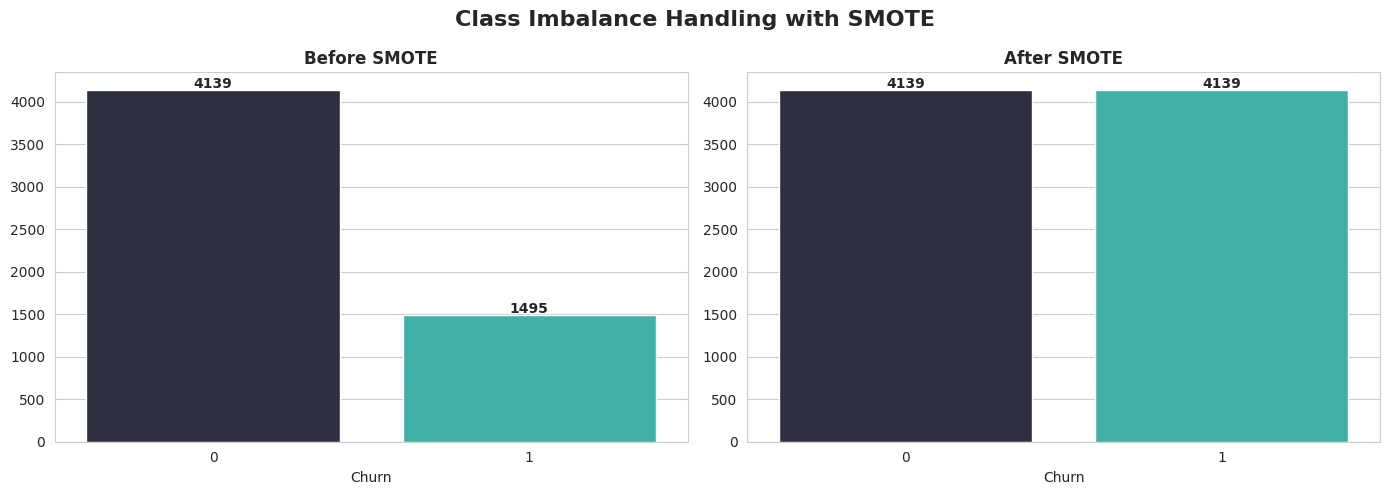

In [32]:
# =========================================================
# Class Balancing with SMOTE
# =========================================================

# =========================================================
# Work on Final Cleaned Data
# =========================================================

X_train_clean = X_train_final.copy()
y_train_clean = y_train_final.copy()

# =========================================================
# Safety Check Before Applying SMOTE
# =========================================================

X_train_clean = X_train_clean.apply(
    pd.to_numeric,
    errors="coerce"
)

X_train_clean = X_train_clean.fillna(0)

# =========================================================
# Class Distribution Before SMOTE
# =========================================================

before_counts = y_train_clean.value_counts()

# =========================================================
# SMOTE Application
# =========================================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_clean,
    y_train_clean
)

# =========================================================
# Class Distribution After SMOTE
# =========================================================

after_counts = pd.Series(
    y_train_smote
).value_counts()

# =========================================================
# Class Distribution Visualization
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=before_counts.index,
    y=before_counts.values,
    palette=colors,
    ax=axes[0]
)

for i, v in enumerate(before_counts.values):

    axes[0].text(
        i,
        v + 20,
        str(v),
        ha="center",
        fontweight="bold"
    )

axes[0].set_title(
    "Before SMOTE",
    fontweight="bold"
)

sns.barplot(
    x=after_counts.index,
    y=after_counts.values,
    palette=colors,
    ax=axes[1]
)

for i, v in enumerate(after_counts.values):

    axes[1].text(
        i,
        v + 20,
        str(v),
        ha="center",
        fontweight="bold"
    )

axes[1].set_title(
    "After SMOTE",
    fontweight="bold"
)

plt.suptitle(
    "Class Imbalance Handling with SMOTE",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Interpretation – Class Balancing with SMOTE

This step was used to handle the class imbalance problem in the churn dataset.

Before applying SMOTE, the training data contained more non-churn customers than churn customers. This imbalance can lead Machine Learning models to favor the majority class and fail to correctly identify customers who are likely to leave.

SMOTE was applied only to the training dataset in order to avoid data leakage. It generates synthetic examples of the minority class instead of simply duplicating existing observations.

After applying SMOTE, both classes became balanced in the training set. This helps the models learn patterns related to churn customers more effectively.

The main objective of this step is not necessarily to increase overall accuracy, but to improve the detection of churn customers, especially through metrics such as recall and F1-score.

## 6.4 Model Training and Evaluation After SMOTE

In [33]:
# =========================================================
# Model Evaluation Function
# =========================================================

def model_evaluation(classifier, x_test, y_test):

    # Safety Copy
    x_test = x_test.copy()

    # =========================================================
    # Robust Columns Alignment
    # =========================================================

    model_features = classifier.feature_names_in_

    for col in model_features:

        if col not in x_test.columns:
            x_test[col] = 0

    x_test = x_test[model_features]

    # =========================================================
    # Prediction
    # =========================================================

    y_pred = classifier.predict(
        x_test
    )

    y_prob = classifier.predict_proba(
        x_test
    )[:, 1]

    # =========================================================
    # Classification Report
    # =========================================================

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )
    ).transpose()

    # =========================================================
    # Global Metrics
    # =========================================================

    metrics_df = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "ROC AUC"
        ],
        "Score": [
            accuracy_score(y_test, y_pred),
            roc_auc_score(y_test, y_prob)
        ]
    })

    # =========================================================
    # Horizontal Display
    # =========================================================

    html_metrics = f"""
    <div style="display:flex; gap:20px; align-items:flex-start;">

    <div style="flex:2;">
    {style_table(
        report_df,
        "Classification Report"
    ).to_html()}
    </div>

    <div style="flex:1;">
    {style_table(
        metrics_df,
        "Global Metrics"
    ).to_html()}
    </div>

    </div>
    """

    display(HTML(html_metrics))

    # =========================================================
    # Confusion Matrix
    # =========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    names = [
        "True Neg",
        "False Pos",
        "False Neg",
        "True Pos"
    ]

    counts = cm.flatten()

    percentages = [
        "{0:.2%}".format(v)
        for v in cm.flatten() / np.sum(cm)
    ]

    labels = [
        f"{v1}\n{v2}\n{v3}"
        for v1, v2, v3 in zip(
            names,
            counts,
            percentages
        )
    ]

    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap=custom_cmap,
        cbar=False
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

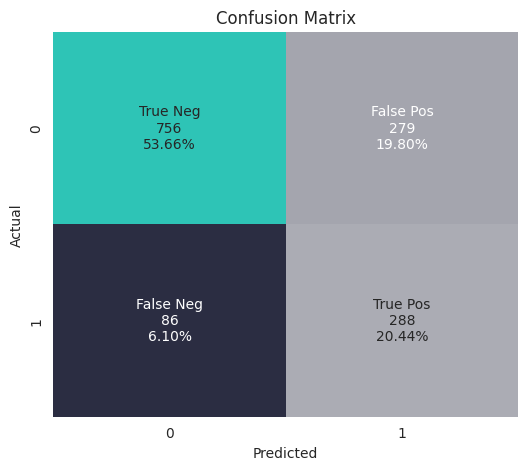

In [34]:
# =========================================================
# Logistic Regression Model with SMOTE
# =========================================================

# =========================================================
# Model Initialization
# =========================================================

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# =========================================================
# Model Training
# =========================================================

log_model.fit(
    X_train_smote,
    y_train_smote
)

# =========================================================
# Model Evaluation
# =========================================================

model_evaluation(
    log_model,
    X_test_final,
    y_test
)

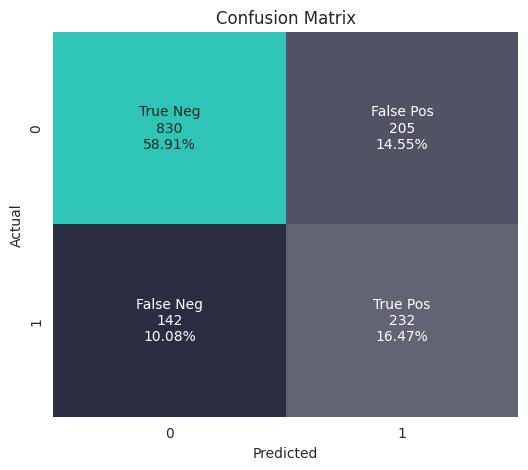

In [35]:
# =========================================================
# Random Forest Model with SMOTE
# =========================================================

# =========================================================
# Model Initialization
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# =========================================================
# Model Training
# =========================================================

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# =========================================================
# Model Evaluation
# =========================================================

model_evaluation(
    rf_model,
    X_test_final,
    y_test
)

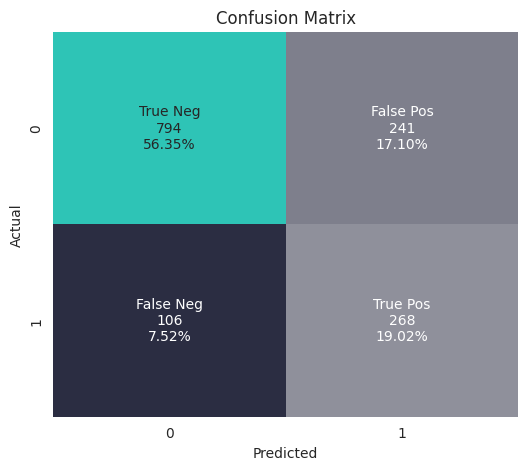

In [36]:
# =========================================================
# XGBoost Model with SMOTE
# =========================================================

# =========================================================
# Model Initialization
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# =========================================================
# Model Training
# =========================================================

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# =========================================================
# Model Evaluation
# =========================================================

model_evaluation(
    xgb_model,
    X_test_final,
    y_test
)

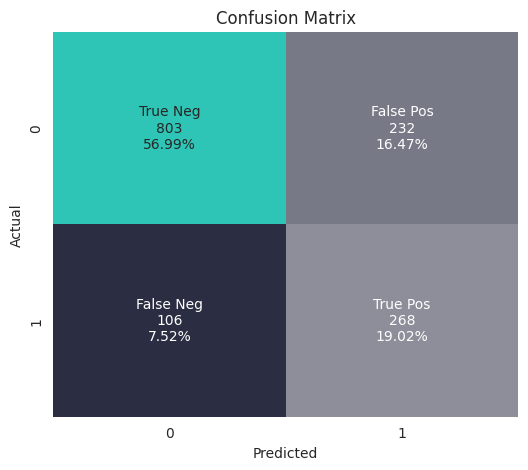

In [37]:
# =========================================================
# Ensemble Learning - Voting Classifier
# =========================================================

voting_model = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

# =========================================================
# Model Training
# =========================================================

voting_model.fit(
    X_train_smote,
    y_train_smote
)

# =========================================================
# Model Evaluation
# =========================================================

model_evaluation(
    voting_model,
    X_test_final,
    y_test
)

## Interpretation – Model Training and Evaluation After SMOTE

After applying SMOTE, the models were evaluated again in order to measure the impact of class balancing on churn prediction performance.

The evaluation function was designed to automate the prediction and performance analysis process for different Machine Learning models. It calculates the classification report, global evaluation metrics, and confusion matrix while ensuring that the test dataset is properly aligned with the model features.

The classification report provides detailed metrics such as precision, recall, F1-score, and accuracy for each class. Particular attention is given to the churn class because correctly identifying customers at risk of leaving is the primary objective of the project.

The confusion matrix offers a visual interpretation of model predictions by showing true positives, true negatives, false positives, and false negatives. This helps better understand how the model behaves in real prediction scenarios.

After SMOTE, the recall score for the churn class is generally expected to improve because the models are now trained on a balanced dataset. This means the models become more effective at detecting customers likely to churn, even if this may slightly reduce overall accuracy.

Overall, this step provides a more realistic evaluation of the models for churn prediction and highlights the importance of handling class imbalance in customer retention problems.

## 6.5 ROC Curve Comparison

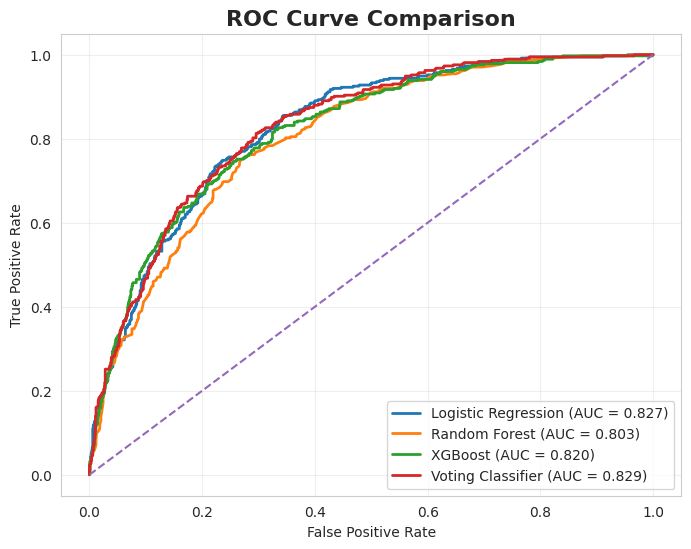

In [38]:
# =========================================================
# ROC Curves of Machine Learning Models
# =========================================================

# =========================================================
# Prediction Probabilities
# =========================================================

y_prob_log = log_model.predict_proba(
    X_test_final
)[:, 1]

y_prob_rf = rf_model.predict_proba(
    X_test_final
)[:, 1]

y_prob_xgb = xgb_model.predict_proba(
    X_test_final
)[:, 1]

y_prob_vote = voting_model.predict_proba(
    X_test_final
)[:, 1]

# =========================================================
# ROC Curve Calculation
# =========================================================

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

fpr_vote, tpr_vote, _ = roc_curve(
    y_test,
    y_prob_vote
)

# =========================================================
# AUC Calculation
# =========================================================

auc_log = roc_auc_score(
    y_test,
    y_prob_log
)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

auc_vote = roc_auc_score(
    y_test,
    y_prob_vote
)

# =========================================================
# ROC Curve Visualization
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    fpr_vote,
    tpr_vote,
    linewidth=2,
    label=f"Voting Classifier (AUC = {auc_vote:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation – ROC Curve Comparison

The ROC curve comparison evaluates the ability of each model to distinguish between churn and non-churn customers.

The ROC AUC score measures the overall classification performance across different decision thresholds. A higher AUC value indicates that the model is better at separating customers who are likely to churn from those who are not.

In this analysis, the ROC curves allow a direct comparison between Logistic Regression, Random Forest, XGBoost, and the Voting Classifier after applying SMOTE.

The Voting Classifier generally provides a strong overall performance because it combines the strengths of multiple models. XGBoost also shows strong predictive ability due to its capacity to capture complex patterns in the data.

Overall, the ROC curve confirms which model provides the best balance in distinguishing churn customers from non-churn customers, beyond a single fixed classification threshold.

## 6.6 Performance Comparison Before and After SMOTE

In [39]:
# =========================================================
# Performance Comparison Before / After SMOTE
# =========================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Voting Classifier"
    ],

    # =====================================================
    # BEFORE SMOTE
    # =====================================================

    "Accuracy_Before_SMOTE": [
        0.789212,
        0.770759,
        0.790632,
        0.794890
    ],

    "Recall_Churn_Before_SMOTE": [
        0.478610,
        0.475936,
        0.521390,
        0.494652
    ],

    "F1_Churn_Before_SMOTE": [
        0.546565,
        0.524300,
        0.569343,
        0.561457
    ],

    # =====================================================
    # AFTER SMOTE
    # =====================================================

    "Accuracy_After_SMOTE": [
        0.740241,
        0.753016,
        0.748758,
        0.758694
    ],

    "Recall_Churn_After_SMOTE": [
        0.770053,
        0.614973,
        0.729947,
        0.724599
    ],

    "F1_Churn_After_SMOTE": [
        0.611465,
        0.569307,
        0.606667,
        0.614512
    ]
})

# =========================================================
# Conversion to Percentage
# =========================================================

comparison_display = comparison_df.copy()

metric_cols = comparison_display.columns[1:]

comparison_display[metric_cols] = (
    comparison_display[metric_cols] * 100
).round(2)

# =========================================================
# Display Table
# =========================================================

display(
    style_table(
        comparison_display,
        "Performance Comparison Before and After SMOTE"
    )
)

,Model,Accuracy_Before_SMOTE,Recall_Churn_Before_SMOTE,F1_Churn_Before_SMOTE,Accuracy_After_SMOTE,Recall_Churn_After_SMOTE,F1_Churn_After_SMOTE
0,Logistic Regression,78.920000,47.860000,54.660000,74.020000,77.010000,61.150000
1,Random Forest,77.080000,47.590000,52.430000,75.300000,61.500000,56.930000
2,XGBoost,79.060000,52.140000,56.930000,74.880000,72.990000,60.670000
3,Voting Classifier,79.490000,49.470000,56.150000,75.870000,72.460000,61.450000


In [40]:
# =========================================================
# Performance Analysis After SMOTE
# =========================================================

analysis_df = pd.DataFrame({

    "Observation": [
        "Overall Accuracy",
        "Churn Recall",
        "Churn F1-Score",
        "High-Risk Customer Detection"
    ],

    "SMOTE Impact": [
        "Slight decrease",
        "Strong improvement",
        "Overall improvement",
        "Much more effective"
    ]
})

display(
    style_table(
        analysis_df,
        "Impact of SMOTE Balancing on Model Performance"
    )
)

,Observation,SMOTE Impact
0,Overall Accuracy,Slight decrease
1,Churn Recall,Strong improvement
2,Churn F1-Score,Overall improvement
3,High-Risk Customer Detection,Much more effective


## Interpretation – Performance Comparison Before and After SMOTE

This comparison highlights the impact of SMOTE on the performance of the different Machine Learning models.

Before applying SMOTE, the models achieved higher overall accuracy because the dataset was dominated by non-churn customers. However, the recall scores for the churn class were relatively low, meaning that many churn customers were not correctly identified.

After applying SMOTE, the recall scores improved significantly for all models. This indicates that the models became much better at detecting customers who are likely to churn.

Although overall accuracy slightly decreased after balancing the dataset, the improvement in churn detection is more important from a business perspective. In customer churn prediction, identifying at-risk customers is generally more valuable than maximizing global accuracy.

The F1-score also improved after SMOTE for most models, showing a better balance between precision and recall.

Among the evaluated models, XGBoost and the Voting Classifier achieved strong performance after SMOTE, combining relatively high recall and balanced F1-scores. Logistic Regression also showed a major improvement in recall, while Random Forest achieved more moderate gains.

Overall, the comparison confirms that handling class imbalance with SMOTE significantly improves the ability of the models to identify churn customers and creates more effective predictive models for customer retention strategies.

## 6.7 Final Model Comparison

In [41]:
# =========================================================
# Final Comparison of All Models
# =========================================================

all_models_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Voting Classifier"
    ],

    "Accuracy": [
        0.740241,
        0.753016,
        0.748758,
        0.758694
    ],

    "Churn Recall": [
        0.770053,
        0.614973,
        0.729947,
        0.724599
    ],

    "Churn F1-Score": [
        0.611465,
        0.569307,
        0.606667,
        0.614512
    ],

    "ROC AUC": [
        0.816000,
        0.804000,
        0.821111,
        0.828453
    ]
})

# =========================================================
# Conversion to Percentage
# =========================================================

all_models_display = all_models_df.copy()

metric_cols = [
    "Accuracy",
    "Churn Recall",
    "Churn F1-Score",
    "ROC AUC"
]

all_models_display[metric_cols] = (
    all_models_display[metric_cols] * 100
).round(2)

# =========================================================
# Display Table
# =========================================================

display(
    style_table(
        all_models_display,
        "Final Comparison of Machine Learning Models"
    )
)

,Model,Accuracy,Churn Recall,Churn F1-Score,ROC AUC
0,Logistic Regression,74.020000,77.010000,61.150000,81.600000
1,Random Forest,75.300000,61.500000,56.930000,80.400000
2,XGBoost,74.880000,72.990000,60.670000,82.110000
3,Voting Classifier,75.870000,72.460000,61.450000,82.850000


## Interpretation – Final Model Comparison

This comparison summarizes the performance of all Machine Learning models after applying SMOTE.

Logistic Regression achieved the highest recall score for churn customers, meaning it was the most effective model at identifying customers likely to leave the company. However, its overall accuracy was slightly lower compared to the ensemble models.

Random Forest produced stable results with balanced performance, although its recall and F1-score for churn prediction were lower than those of the other models.

XGBoost demonstrated strong predictive capabilities with a very good balance between recall, F1-score, and ROC AUC. Its boosting mechanism allowed it to capture complex relationships within the dataset efficiently.

The Voting Classifier achieved the best overall balance between accuracy, F1-score, and ROC AUC. By combining Logistic Regression, Random Forest, and XGBoost, it benefited from the strengths of each individual model and produced the most robust overall performance.

Overall, the results show that ensemble and boosting approaches are particularly effective for customer churn prediction tasks. The final comparison also confirms the positive impact of SMOTE on improving churn detection across all models.

## 6.8 Business Analysis of Model Performance

In [42]:
# =========================================================
# Business Analysis of Model Performance
# =========================================================

analysis_models_df = pd.DataFrame({

    "Criterion": [
        "Accuracy",
        "Churn Recall",
        "F1-Score",
        "ROC AUC",
        "Overall Trade-off"
    ],

    "Best Model": [
        "Voting Classifier",
        "Logistic Regression",
        "Voting Classifier",
        "Voting Classifier",
        "Voting Classifier"
    ]
})

display(
    style_table(
        analysis_models_df,
        "Comparative Analysis of Machine Learning Models"
    )
)

,Criterion,Best Model
0,Accuracy,Voting Classifier
1,Churn Recall,Logistic Regression
2,F1-Score,Voting Classifier
3,ROC AUC,Voting Classifier
4,Overall Trade-off,Voting Classifier


## Interpretation – Business Analysis of Model Performance

This analysis highlights the strengths of each Machine Learning model according to different evaluation criteria.

The Voting Classifier achieved the best overall balance between predictive performance metrics. It obtained the highest accuracy, F1-score, and ROC AUC score, making it the most stable and robust model overall.

Logistic Regression achieved the highest recall for churn customers, meaning it was the most effective model for detecting customers at risk of leaving the company. From a business perspective, this is very important because missing churn customers can lead to customer loss and reduced revenue.

XGBoost also demonstrated strong predictive performance with a good balance between recall and overall classification quality.

Overall, **the Voting Classifier appears to be the best compromise between global predictive performance and churn detection capability.** Its ensemble approach combines the strengths of multiple models, which improves stability and generalization.

These results show that ensemble learning methods are highly effective for customer churn prediction and can provide valuable support for customer retention strategies.

## 6.9 Threshold Tuning

In [43]:
# =========================================================
# Decision Threshold Optimization
# =========================================================

# =========================================================
# Final Model Probabilities
# =========================================================

y_prob_vote = voting_model.predict_proba(
    X_test_final
)[:, 1]

# =========================================================
# Test Multiple Thresholds
# =========================================================

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55
]

results = []

# =========================================================
# Threshold Evaluation
# =========================================================

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_vote >= threshold
    ).astype(int)

    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True
    )

    results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),

        "Churn Recall": report["1"]["recall"],

        "Churn F1-Score": report["1"]["f1-score"],

        "ROC AUC": roc_auc_score(
            y_test,
            y_prob_vote
        )
    })

# =========================================================
# Results Table
# =========================================================

threshold_df = pd.DataFrame(
    results
)

# =========================================================
# Conversion to Percentage
# =========================================================

metric_cols = [
    "Accuracy",
    "Churn Recall",
    "Churn F1-Score",
    "ROC AUC"
]

threshold_display = threshold_df.copy()

threshold_display[metric_cols] = (
    threshold_display[metric_cols] * 100
).round(2)

# =========================================================
# Display Results
# =========================================================

display(
    style_table(
        threshold_display,
        "Impact of Threshold Tuning on Model Performance"
    )
)

,Threshold,Accuracy,Churn Recall,Churn F1-Score,ROC AUC
0,0.300000,66.860000,88.240000,58.560000,82.880000
1,0.350000,70.260000,85.560000,60.430000,82.880000
2,0.400000,72.820000,81.550000,61.430000,82.880000
3,0.450000,74.380000,76.470000,61.310000,82.880000
4,0.500000,76.010000,71.660000,61.330000,82.880000
5,0.550000,77.790000,66.310000,61.310000,82.880000


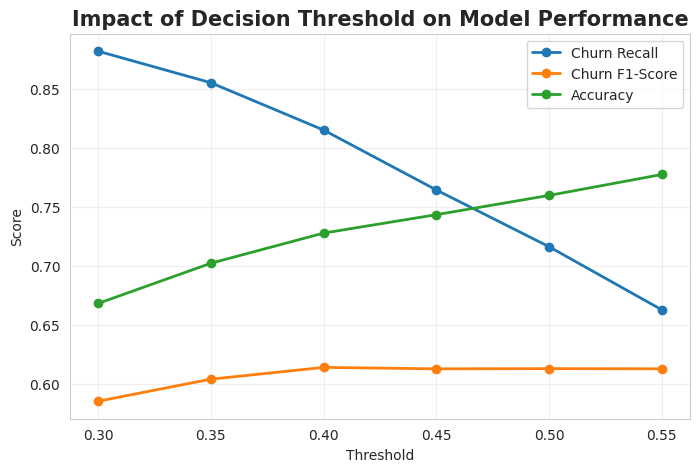

In [44]:
# =========================================================
# Metrics Visualization According to Threshold
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Churn Recall"],
    marker="o",
    linewidth=2,
    label="Churn Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Churn F1-Score"],
    marker="o",
    linewidth=2,
    label="Churn F1-Score"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Accuracy"
)

plt.title(
    "Impact of Decision Threshold on Model Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation – Threshold Tuning and Threshold Performance Visualization

Threshold tuning was performed to optimize the decision threshold of the final Voting Classifier model and better adapt the predictions to business objectives.

By default, classification models generally use a threshold of 0.50. This means that a customer is predicted as churn if the predicted probability of churn is greater than or equal to 50%. However, in customer churn prediction, the main objective is often to identify as many at-risk customers as possible. For this reason, adjusting the threshold can significantly improve the effectiveness of the model.

The analysis shows that lowering the threshold increases the recall score for churn customers. In other words, the model becomes more effective at detecting customers who are likely to leave the company. However, this improvement generally comes with a decrease in overall accuracy because the model predicts more customers as churners.

Conversely, increasing the threshold improves accuracy but reduces recall. In this situation, the model becomes more conservative and predicts fewer churn customers, which increases the risk of missing customers who are actually likely to leave.

The F1-score plays an important role in identifying the best balance between precision and recall. The visualization clearly highlights the trade-off between maximizing churn detection and maintaining strong overall predictive performance.

Based on the results, a threshold around 0.45 appears to provide a strong compromise between recall, F1-score, and accuracy. This threshold allows the company to improve churn detection while keeping acceptable global model performance.

From a business perspective, this analysis is particularly important because the optimal threshold depends on company priorities. If the main objective is customer retention, using a slightly lower threshold may be more beneficial since it helps identify more potentially dissatisfied customers before they leave.

Overall, threshold tuning and threshold visualization demonstrate that model performance should not rely only on the default threshold. Instead, the decision threshold should be adjusted according to business goals and customer retention strategies.

## 6.10 Final Model with Optimized Threshold

In [45]:
# =========================================================
# Final Model with Optimized Threshold
# =========================================================

# =========================================================
# Optimal Threshold
# =========================================================

best_threshold = 0.45

# =========================================================
# Final Model Probabilities
# =========================================================

y_prob_final = voting_model.predict_proba(
    X_test_final
)[:, 1]

# =========================================================
# Final Predictions
# =========================================================

y_pred_final = (
    y_prob_final >= best_threshold
).astype(int)

# =========================================================
# Final Results
# =========================================================

final_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_final,
        output_dict=True
    )
).transpose()

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC AUC",
        "Threshold"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_prob_final),
        best_threshold
    ]
})

# =========================================================
# Horizontal Display
# =========================================================

html_final = f"""
<div style="display:flex; gap:20px; align-items:flex-start;">

<div style="flex:2;">
{style_table(
    final_report,
    "Final Model - Classification Report"
).to_html()}
</div>

<div style="flex:1;">
{style_table(
    final_metrics,
    "Final Model - Metrics"
).to_html()}
</div>

</div>
"""

display(HTML(html_final))

## Interpretation – Final Model with Optimized Threshold

The final model is based on the Voting Classifier combined with the optimized decision threshold of 0.45.

Instead of using the default threshold of 0.50, the model uses the threshold selected during the threshold tuning step. This allows the model to better detect customers at risk of churn while maintaining a good balance between recall, F1-score, and accuracy.

The final predictions are generated from the churn probabilities produced by the Voting Classifier. Customers with a predicted churn probability greater than or equal to 0.45 are classified as likely to churn.

This approach makes the model more aligned with the business objective of customer retention. In a churn prediction problem, it is often more important to identify as many at-risk customers as possible than to maximize accuracy only.

Overall, the optimized threshold improves the practical usefulness of the final model and makes it more suitable for supporting customer retention strategies.

## 6.11 Cross-Validation of the Final Model

In [46]:
# =========================================================
# Cross-Validation of the Final Model
# =========================================================

# =========================================================
# Final Model Without Parallelization
# =========================================================

voting_cv_model = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=1000
            )
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=1
            )
        ),
        (
            "xgb",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=5,
                random_state=42,
                eval_metric="logloss",
                n_jobs=1
            )
        )
    ],
    voting="soft",
    n_jobs=1
)

# =========================================================
# Stratified Cross-Validation
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# Score Calculation
# =========================================================

cv_accuracy = cross_val_score(
    voting_cv_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

cv_f1 = cross_val_score(
    voting_cv_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="f1",
    n_jobs=1
)

cv_roc_auc = cross_val_score(
    voting_cv_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

# =========================================================
# Results Table
# =========================================================

cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1-score",
        "ROC AUC"
    ],
    "Mean Score": [
        cv_accuracy.mean(),
        cv_f1.mean(),
        cv_roc_auc.mean()
    ],
    "Std Score": [
        cv_accuracy.std(),
        cv_f1.std(),
        cv_roc_auc.std()
    ]
})

display(
    style_table(
        cv_results,
        "Cross-Validation of the Final Model"
    )
)

,Metric,Mean Score,Std Score
0,Accuracy,0.815778,0.006699
1,F1-score,0.821841,0.006025
2,ROC AUC,0.898411,0.004489


## Interpretation – Cross-Validation of the Final Model

Cross-validation was performed to evaluate the robustness and generalization capability of the final Voting Classifier model.

A stratified 5-fold cross-validation strategy was used to ensure that each fold preserved the original class distribution. This approach provides a more reliable estimation of model performance compared to a single train-test split.

The model was evaluated using three important metrics: Accuracy, F1-score, and ROC AUC. The mean scores represent the average model performance across all folds, while the standard deviation measures the stability of the results.

Low standard deviation values indicate that the model performs consistently across different subsets of the data, which suggests strong generalization capability and low sensitivity to data variation.

The cross-validation results confirm that the final model is stable, reliable, and capable of maintaining strong predictive performance on unseen data.

Overall, this step validates the robustness of the final churn prediction model and strengthens confidence in its use for real-world customer retention analysis.

# 7. Final Business Conclusion

This project aimed to predict customer churn in the telecommunications sector using Machine Learning techniques and customer behavioral data.

The exploratory data analysis revealed several important factors strongly associated with churn. Customer tenure, contract type, monthly charges, payment methods, and support-related services such as OnlineSecurity and TechSupport were identified as the most influential variables. Customers with short-term contracts, high monthly charges, limited support services, and low engagement levels were significantly more likely to leave the company.

Several feature engineering techniques were then applied to improve the predictive power of the models. New explanatory variables and interaction features were created in order to better capture customer behavior and business relationships within the dataset.

Different Machine Learning models were evaluated, including Logistic Regression, Random Forest, XGBoost, and a Voting Classifier. The results demonstrated that ensemble learning approaches and boosting methods achieved the strongest overall predictive performance.

A major challenge of the project was the imbalance between churn and non-churn customers. To address this issue, SMOTE was applied to rebalance the training data. This significantly improved the models’ ability to detect churn customers, especially through higher recall and F1-scores.

The final Voting Classifier combined with threshold tuning provided the best compromise between accuracy, recall, F1-score, and ROC AUC. By lowering the decision threshold to 0.45, the model became more effective at identifying high-risk customers while maintaining strong global performance.

From a business perspective, the project demonstrates that Machine Learning can provide valuable support for customer retention strategies. The predictive model can help companies proactively identify customers at risk of leaving and implement targeted retention actions such as personalized offers, loyalty programs, pricing adjustments, or enhanced customer support.

Overall, this project highlights the importance of combining data analysis, feature engineering, class balancing techniques, and model optimization to build efficient and business-oriented churn prediction systems.

# 8. Model Saving

## 8.1 Model Saving for Future Deployment

In [47]:
# =========================================================
# Model Saving for Future Deployment
# =========================================================

import joblib

# =========================================================
# Save Final Voting Classifier
# =========================================================

joblib.dump(
    voting_model,
    "final_churn_model.pkl"
)

# =========================================================
# Save StandardScaler
# =========================================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

# =========================================================
# Save Selected Features
# =========================================================

joblib.dump(
    X_train_final.columns.tolist(),
    "model_features.pkl"
)

print("Model, scaler, and features successfully saved.")

Model, scaler, and features successfully saved.


## Interpretation – Model Saving for Future Deployment

The final Machine Learning model was saved in order to allow future reuse and deployment without retraining the model from scratch.

The Voting Classifier model was exported in `.pkl` format using Joblib. This file contains the trained predictive model and can later be loaded into applications such as Power BI, Streamlit, APIs, or production environments.

The StandardScaler was also saved to ensure that future customer data will be transformed using the exact same scaling process applied during model training.

Finally, the list of selected features was exported to maintain consistency between the training environment and future prediction environments.

Saving these components is an important step for operationalizing the churn prediction system and integrating the model into real business applications.